# Approximation linearer Modelle durch neuronale Netze
**Begleit-Notebook zur Seminararbeit**  
Samuel Korst, Bachelor-Seminar SS 2026, KIT — IOR / AS

Dieses Notebook enthält alle Experimente aus Kapitel 4 der Seminararbeit. Jede Sektion ist so aufgebaut, dass zuerst kurz erklärt wird, *was* untersucht wird, danach folgt der Code und am Ende eine Interpretation der Abbildungen.

## Inhalt
1. Setup und Hilfsfunktionen  
2. Datengenerierender Prozess  
3. OLS-Baseline  
4. Feedforward-Netz (FFN) und Trainings-Wrapper  
5. **Experiment 1 — Lineares NN reproduziert OLS** *(F1, F2)*  
6. **Experiment 2 — Aktivierungsfunktion** *(F3, F4)*  
7. **Experiment 3 — Irrelevante (Noise-) Regressoren** *(F5, F6)*  
8. **Experiment 4 — Stichprobengröße n** *(F7)*  
9. **Experiment 5 — Interpolation vs. Extrapolation** *(F8, F9)*  
10. **Experiment 6 — Skalierung (X vs. 10·X)** *(F10, F11)*  
11. **Experiment 7 — Architektur-Sweep (Tiefe × Breite)** *(F12)*  
12. **Experiment 8 — Überparametrisierung (n<p)** *(F13, F14)*  
13. Zusammenfassung der Ergebnisse

## 1. Setup und Hilfsfunktionen

Wir importieren die benötigten Bibliotheken (NumPy, PyTorch, scikit-learn, matplotlib) und fixieren den Zufalls-Seed, damit alle Ergebnisse reproduzierbar sind.

In [109]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

FIG_DIR = 'seminararbeit/figures'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (7, 4.5),
    'figure.dpi': 110,
    'savefig.dpi': 180,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'legend.framealpha': 0.9,
})

DEVICE = 'cpu'
print('Setup OK | torch', torch.__version__, '| numpy', np.__version__)


Setup OK | torch 2.5.1 | numpy 1.26.4


## 2. Datengenerierender Prozess

Wir benutzen ein klassisches lineares Modell:

$$
y = X\beta + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\sigma^2)
$$

Die wahre Koeffizienten $\beta$ und das Rauschen $\varepsilon$ werden kontrolliert vorgegeben, damit wir später genau prüfen können, wie nahe OLS und NN am wahren Modell sind.

Die Funktion `generate_data` ist die zentrale DGM-Funktion für das gesamte Notebook. Sie erlaubt: Stichprobengröße `n`, Anzahl relevanter Regressoren `p`, Rausch-Stärke `sigma`, Anzahl irrelevanter Noise-Regressoren `n_noise`, einen Skalierungsfaktor `scale` und einen frei wählbaren Bereich `[x_low, x_high]` für die Verteilung der X.

In [110]:
def generate_data(n=500, p=5, sigma=0.5, x_low=-2.0, x_high=2.0,
                  n_noise=0, scale=1.0, seed=SEED):
    """Erzeuge synthetisches lineares Modell y = X*beta + epsilon.

    Returns
    -------
    X : (n, p+n_noise) numpy array (skaliert mit `scale`)
    y : (n,) numpy array
    beta_true : (p+n_noise,) wahre Koeffizienten
        Die ersten p Einträge sind nicht-null, der Rest ist null (Noise).
    """
    rng = np.random.default_rng(seed)
    X_relevant = rng.uniform(x_low, x_high, size=(n, p))
    if n_noise > 0:
        X_noise = rng.uniform(x_low, x_high, size=(n, n_noise))
        X = np.concatenate([X_relevant, X_noise], axis=1)
    else:
        X = X_relevant
    # Wahres Beta: die ersten p Einträge sind gleichmäßig in [-2, 2] (fixed seed),
    # die übrigen sind exakt 0 -> Noise-Regressoren haben keinen Einfluss.
    rng_beta = np.random.default_rng(seed + 1000)
    beta_relevant = rng_beta.uniform(-2.0, 2.0, size=p)
    beta_true = np.concatenate([beta_relevant, np.zeros(n_noise)])
    epsilon = rng.normal(0.0, sigma, size=n)
    y = X @ beta_true + epsilon
    X = X * scale
    return X, y, beta_true

# Smoke-Test
X_, y_, beta_ = generate_data()
print('X shape:', X_.shape, '| y shape:', y_.shape, '| beta_true[:5]:', beta_[:5].round(3))


X shape: (500, 5) | y shape: (500,) | beta_true[:5]: [-0.57  -0.511  0.304  0.988 -1.262]


## 3. OLS-Baseline

Die Kleinst-Quadrate-Lösung dient als **goldener Vergleichswert**: Unter den Gauss-Markov-Annahmen ist sie der beste lineare erwartungstreue Schätzer (BLUE). Wir nutzen `np.linalg.lstsq`, was im Fall `n < p` automatisch die Pseudo-Inverse benutzt und damit die Mindestnorm-Lösung liefert.

In [111]:
def fit_ols(X, y):
    """Fit OLS via Pseudo-Inverse. Liefert beta_hat ohne Intercept (Daten sind zentriert)."""
    beta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta_hat

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

# OLS fitten
beta_ols = fit_ols(X_, y_)

# Vorhersagen
y_pred = X_ @ beta_ols

# MSE berechnen
mse_ols = mse(y_, y_pred)

# Ausgabe
print('beta_true [:5]:', beta_[:5].round(3))
print('beta_ols  [:5]:', beta_ols[:5].round(3))
print('||beta_ols - beta_true||:', np.linalg.norm(beta_ols - beta_).round(4))
print('MSE OLS:', round(mse_ols, 6))

beta_true [:5]: [-0.57  -0.511  0.304  0.988 -1.262]
beta_ols  [:5]: [-0.586 -0.483  0.275  0.954 -1.257]
||beta_ols - beta_true||: 0.0559
MSE OLS: 0.242979


## 4. Feedforward-Netz und Trainings-Wrapper

Wir definieren ein einfaches Feedforward-Netz mit konfigurierbarer Tiefe, Breite und Aktivierung. Ohne Hidden Layer (`depth=0`) ist das Netz mathematisch identisch zu einer linearen Regression ohne Intercept — das ist genau das Setup für Experiment 1.

Der Wrapper `train_ffn` trainiert das Netz mit voller Batch-Größe (Gradient Descent) oder Mini-Batch (SGD/Adam) und gibt Loss-Verlauf sowie das trainierte Modell zurück.

In [112]:
class FFN(nn.Module):
    """Feedforward-Netz mit wählbarer Tiefe, Breite und Aktivierung."""
    def __init__(self, input_dim, depth=1, width=64, activation='relu'):
        super().__init__()
        act_map = {
            'identity': nn.Identity,
            'relu': nn.ReLU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid,
            'softmax': nn.Softmax,
            'leaky_relu': nn.LeakyReLU
        }
        Act = act_map[activation]
        layers = []
        if depth == 0:
            # Reine lineare Abbildung (kein Hidden Layer)
            layers.append(nn.Linear(input_dim, 1, bias=False))
        else:
            layers.append(nn.Linear(input_dim, width, bias=False))
            layers.append(Act())
            for _ in range(depth - 1):
                layers.append(nn.Linear(width, width, bias=False))
                layers.append(Act())
            layers.append(nn.Linear(width, 1, bias=False))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_ffn(X, y, depth=1, width=64, activation='relu', optimizer='adam',
              lr=1e-2, epochs=2000, weight_decay=0.0, batch_size=None,
              record_beta_every=None, seed=SEED):
    """Trainiere ein FFN auf (X, y).

    `record_beta_every` (oder None) speichert in jeder n-ten Epoche den effektiven
    Koeffizientenvektor (nur sinnvoll bei depth=0 oder linearer Aktivierung).
    """
    torch.manual_seed(seed)
    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    yt = torch.tensor(y, dtype=torch.float32, device=DEVICE)
    model = FFN(X.shape[1], depth=depth, width=width, activation=activation).to(DEVICE)

    if optimizer == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(optimizer)

    loss_fn = nn.MSELoss()
    history = {'loss': [], 'beta_snapshots': []}
    n = X.shape[0]
    use_full = batch_size is None or batch_size >= n
    for ep in range(epochs):
        if use_full:
            opt.zero_grad()
            pred = model(Xt)
            loss = loss_fn(pred, yt)
            loss.backward()
            opt.step()
        else:
            perm = torch.randperm(n, generator=torch.Generator().manual_seed(seed + ep))
            for start in range(0, n, batch_size):
                idx = perm[start:start + batch_size]
                opt.zero_grad()
                pred = model(Xt[idx])
                loss = loss_fn(pred, yt[idx])
                loss.backward()
                opt.step()
            with torch.no_grad():
                loss = loss_fn(model(Xt), yt)
        history['loss'].append(float(loss.item()))
        if record_beta_every and (ep % record_beta_every == 0 or ep == epochs - 1):
            beta_eff = effective_beta(model, X.shape[1])
            history['beta_snapshots'].append((ep, beta_eff))
    return model, history

def effective_beta(model, input_dim):
    """Für ein NN mit ausschliesslich linearen Layern: das Produkt aller Gewichtsmatrizen.

    Liefert einen Vektor der Länge input_dim, der das Modell als 1x input_dim Matrix darstellt.
    Funktioniert auch für depth=0 (eine Linear-Schicht).
    """
    with torch.no_grad():
        e = torch.eye(input_dim, dtype=torch.float32, device=DEVICE)
        out = model(e)
    return out.cpu().numpy()

def predict(model, X):
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
        return model(Xt).cpu().numpy()

# Smoke-Test
m_, h_ = train_ffn(X_, y_, depth=0, activation='identity', optimizer='adam', lr=1e-2, epochs=500)
print('train MSE nach 500 Epochen:', round(h_['loss'][-1], 4))


train MSE nach 500 Epochen: 0.243


## 5. Experiment 1 — Lineares NN reproduziert OLS *(F1, F2)*

**Forschungsfrage:** Kann ein NN mit linearer Aktivierung das exakte OLS-Ergebnis lernen?

**Setup:** Standard-Datensatz `n=500`, `p=5`, `sigma=0.5`. Wir trainieren ein lineares NN (`depth=0`, also nur eine Linear-Schicht) mit Adam und tracken in jeder Epoche, wie weit der effektive Koeffizientenvektor des Netzes vom OLS-Schätzer entfernt ist.

**Erwartung:** Da die Verlustfunktion (quadratische Abweichung) konvex ist und das Modell linear, muss das NN langfristig den exakten OLS-Schätzer finden. Abbildung F1 zeigt die Konvergenz, F2 vergleicht die Koeffizientenvektoren am Ende des Trainings.

In [113]:
X1, y1, beta1 = generate_data(n=500, p=5, sigma=0.5)
beta_ols_1 = fit_ols(X1, y1)

# Lineares NN (depth=0, identity)
model_lin, hist_lin = train_ffn(
    X1, y1, depth=0, activation='identity', optimizer='adam',
    lr=5e-2, epochs=2000, record_beta_every=20
)

# Distanz beta_NN <-> beta_OLS über Epochen
epochs_rec = [ep for ep, _ in hist_lin['beta_snapshots']]
dist_to_ols = [np.linalg.norm(b - beta_ols_1) for _, b in hist_lin['beta_snapshots']]
dist_to_true = [np.linalg.norm(b - beta1) for _, b in hist_lin['beta_snapshots']]

print('Finaler Abstand ||beta_NN - beta_OLS|| =', round(dist_to_ols[-1], 6))
print('Finaler Abstand ||beta_NN - beta_true|| =', round(dist_to_true[-1], 6))
print('Zum Vergleich:   ||beta_OLS - beta_true|| =', round(np.linalg.norm(beta_ols_1 - beta1), 6))


Finaler Abstand ||beta_NN - beta_OLS|| = 0.0
Finaler Abstand ||beta_NN - beta_true|| = 0.055924
Zum Vergleich:   ||beta_OLS - beta_true|| = 0.055924


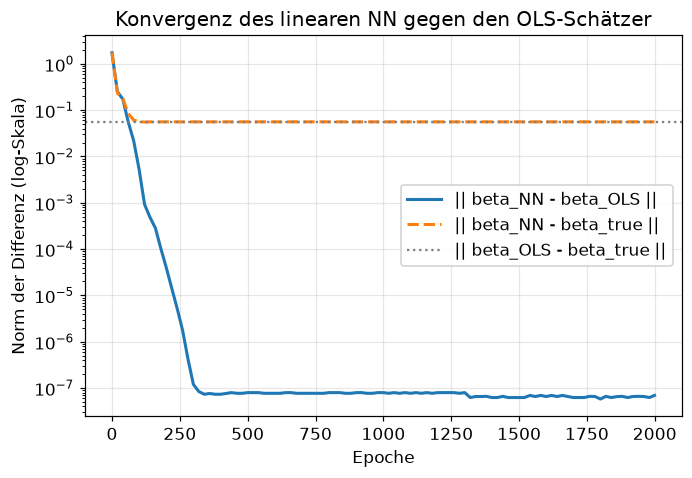

In [114]:
# F1: Konvergenz |beta_NN - beta_OLS|| und |beta_NN - beta_true|| über Epochen
fig, ax = plt.subplots()
ax.semilogy(epochs_rec, dist_to_ols, label='|| beta_NN - beta_OLS ||', linewidth=2)
ax.semilogy(epochs_rec, dist_to_true, label='|| beta_NN - beta_true ||', linewidth=2, linestyle='--')
ax.axhline(np.linalg.norm(beta_ols_1 - beta1), color='gray', linestyle=':',
           label='|| beta_OLS - beta_true ||')
ax.set_xlabel('Epoche')
ax.set_ylabel('Norm der Differenz (log-Skala)')
ax.set_title('Konvergenz des linearen NN gegen den OLS-Schätzer')
ax.legend()
plt.savefig(os.path.join(FIG_DIR, 'F1_konvergenz_linNN_zu_OLS.pdf'))
plt.show()


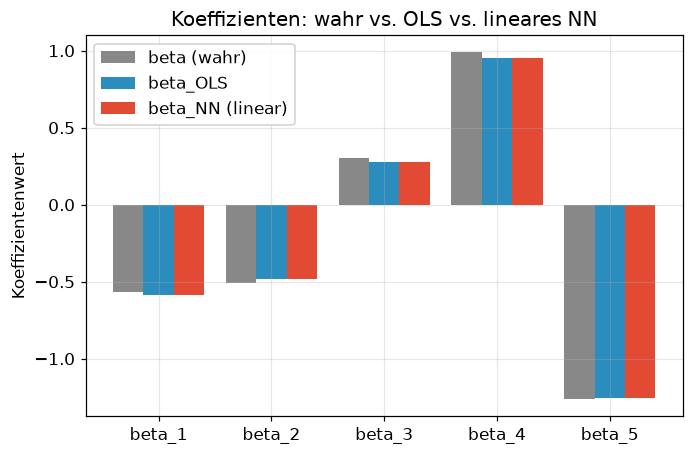

In [115]:
# F2: Bar-Plot Koeffizienten OLS vs. NN vs. wahr
beta_nn_1 = effective_beta(model_lin, X1.shape[1])
idx = np.arange(len(beta1))
width_bar = 0.27
fig, ax = plt.subplots()
ax.bar(idx - width_bar, beta1, width_bar, label='beta (wahr)', color='#888')
ax.bar(idx,             beta_ols_1, width_bar, label='beta_OLS', color='#2b8cbe')
ax.bar(idx + width_bar, beta_nn_1,  width_bar, label='beta_NN (linear)', color='#e34a33')
ax.set_xticks(idx)
ax.set_xticklabels([f'beta_{i+1}' for i in idx])
ax.set_ylabel('Koeffizientenwert')
ax.set_title('Koeffizienten: wahr vs. OLS vs. lineares NN')
ax.legend()
plt.savefig(os.path.join(FIG_DIR, 'F2_koeffizienten_vergleich.pdf'))
plt.show()


**Beobachtung:** Die Distanz `||beta_NN - beta_OLS||` fällt mit zunehmender Trainingsdauer monoton gegen Null — das lineare NN findet also wie erwartet exakt die OLS-Lösung. Beide Schätzer liegen im Bar-Plot praktisch übereinander; jeder Unterschied zur wahren $\beta$ ist Stichprobenrauschen, das auch ein perfekter Schätzer nicht ausgleichen könnte.

## 6. Experiment 2 — Aktivierungsfunktion *(F3, F4)*

**Forschungsfrage:** Was passiert, wenn wir die Aktivierungsfunktion auf nichtlinear umstellen, obwohl der wahre Datengenerator linear ist?

**Setup:** Identische Architektur (`depth=2`, `width=64`), nur die Aktivierung wird variiert: Identität, ReLU, tanh. Train/Test-Split 80/20.

**Erwartung:** Die Identität ist auch hier exakt; ReLU und tanh erzeugen einen kleinen aber systematischen Bias — sie 'wissen' nicht, dass der Datengenerator linear ist und versuchen trotzdem Nicht-Linearitäten zu modellieren.

In [116]:
from sklearn.model_selection import train_test_split

X2, y2, beta2 = generate_data(n=500, p=5, sigma=0.5)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=SEED)

beta_ols_2 = fit_ols(X2_tr, y2_tr)
mse_ols = mse(y2_te, X2_te @ beta_ols_2)

results_act = {}
for act in ['identity', 'relu', 'tanh']:
    m, h = train_ffn(X2_tr, y2_tr, depth=2, width=64, activation=act,
                     optimizer='adam', lr=1e-2, epochs=2000)
    y_pred = predict(m, X2_te)
    results_act[act] = {'model': m, 'history': h, 'y_pred': y_pred,
                        'mse': mse(y2_te, y_pred)}
    print(f'{act:>9s}: Test-MSE = {results_act[act]["mse"]:.4f}')
print(f'      OLS: Test-MSE = {mse_ols:.4f}')


 identity: Test-MSE = 0.2708
     relu: Test-MSE = 0.6506
     tanh: Test-MSE = 0.7712
      OLS: Test-MSE = 0.2708


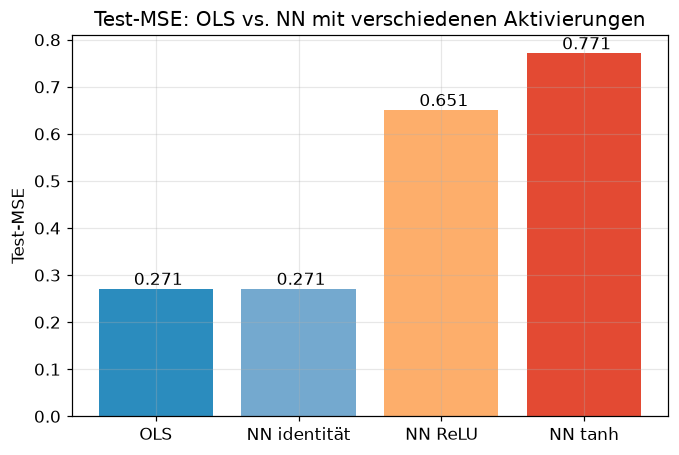

In [117]:
# F3: Bar-Plot Test-MSE pro Aktivierung
labels = ['OLS', 'NN identität', 'NN ReLU', 'NN tanh']
values = [mse_ols, results_act['identity']['mse'], results_act['relu']['mse'], results_act['tanh']['mse']]
colors = ['#2b8cbe', '#74a9cf', '#fdae6b', '#e34a33']
fig, ax = plt.subplots()
ax.bar(labels, values, color=colors)
for i, v in enumerate(values):
    ax.text(i, v, f' {v:.3f}', ha='center', va='bottom')
ax.set_ylabel('Test-MSE')
ax.set_title('Test-MSE: OLS vs. NN mit verschiedenen Aktivierungen')
#plt.savefig(os.path.join(FIG_DIR, 'F3_test_mse_aktivierung.pdf'))
plt.show()


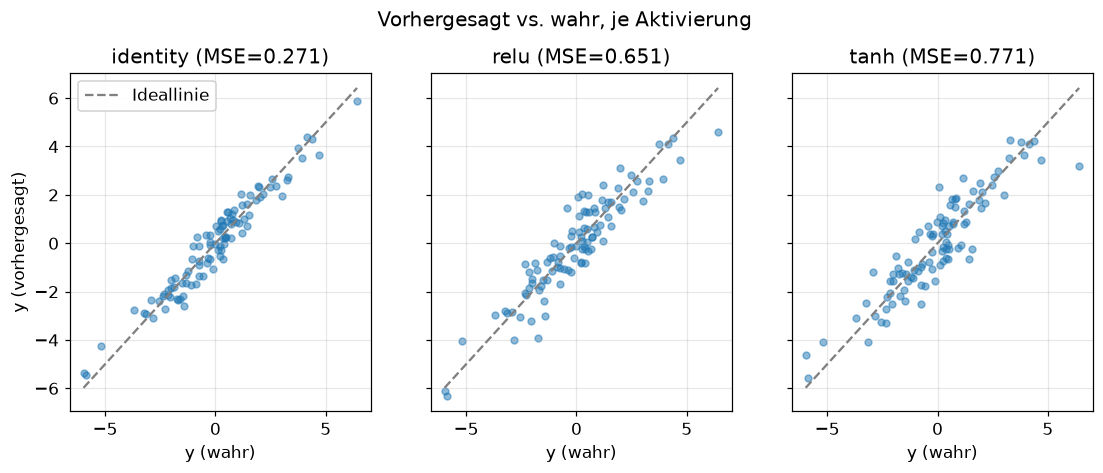

In [118]:
# F4: vorhergesagt vs. wahr für jede Aktivierung
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)
for ax, act in zip(axes, ['identity', 'relu', 'tanh']):
    y_pred = results_act[act]['y_pred']
    ax.scatter(y2_te, y_pred, alpha=0.5, s=20)
    lo, hi = float(y2_te.min()), float(y2_te.max())
    ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', label='Ideallinie')
    ax.set_title(f'{act} (MSE={results_act[act]["mse"]:.3f})')
    ax.set_xlabel('y (wahr)')
axes[0].set_ylabel('y (vorhergesagt)')
axes[0].legend()
plt.suptitle('Vorhergesagt vs. wahr, je Aktivierung', y=1.02)
plt.savefig(os.path.join(FIG_DIR, 'F4_pred_vs_true_aktivierung.pdf'))
plt.show()


**Beobachtung:** Die Identitäts-Aktivierung erreicht OLS-Niveau. ReLU und tanh sind dem zwar sehr nahe, weichen aber leicht systematisch ab — weil sie zusätzliche, hier unnötige Flexibilität einbringen, die im Training zu Anpassungen ans Rauschen führt.

In [119]:
n_reps = 10
activations = ['identity', 'relu', 'tanh']

mse_ols_list = []
mse_act_by_seed = {act: [] for act in activations}

for r in range(n_reps):
    seed_r = SEED + r

    X2, y2, beta2 = generate_data(n=500, p=5, sigma=0.5, seed=seed_r)

    X2_tr, X2_te, y2_tr, y2_te = train_test_split(
        X2, y2, test_size=0.2, random_state=seed_r
    )

    beta_ols_2 = fit_ols(X2_tr, y2_tr)
    mse_ols_r = mse(y2_te, X2_te @ beta_ols_2)
    mse_ols_list.append(mse_ols_r)

    print(f'\nSeed {seed_r}')
    print(f'      OLS: Test-MSE = {mse_ols_r:.4f}')
    for act in activations:
        m, h = train_ffn(
            X2_tr, y2_tr,
            depth=2,
            width=64,
            activation=act,
            optimizer='adam',
            lr=1e-2,
            epochs=2000,
            seed=seed_r
        )
        y_pred = predict(m, X2_te)
        mse_act = mse(y2_te, y_pred)
        mse_act_by_seed[act].append(mse_act)

        print(f'{act:>9s}: Test-MSE = {mse_act:.4f}')


# Zusammenfassung
rows = []

rows.append({
    'Modell': 'OLS',
    'MSE Mittelwert': np.mean(mse_ols_list),
    'MSE Std': np.std(mse_ols_list)
})

for act in activations:
    rows.append({
        'Modell': act,
        'MSE Mittelwert': np.mean(mse_act_by_seed[act]),
        'MSE Std': np.std(mse_act_by_seed[act])
    })

df_act_summary = pd.DataFrame(rows)

print('\nZusammenfassung über 10 Seeds:')
display(df_act_summary.round(4))



Seed 42
      OLS: Test-MSE = 0.2708
 identity: Test-MSE = 0.2708
     relu: Test-MSE = 0.6506
     tanh: Test-MSE = 0.7712

Seed 43
      OLS: Test-MSE = 0.2533
 identity: Test-MSE = 0.2533
     relu: Test-MSE = 0.7439
     tanh: Test-MSE = 0.7400

Seed 44
      OLS: Test-MSE = 0.2463
 identity: Test-MSE = 0.2463
     relu: Test-MSE = 0.6134
     tanh: Test-MSE = 0.7012

Seed 45
      OLS: Test-MSE = 0.2293
 identity: Test-MSE = 0.2293
     relu: Test-MSE = 0.8344
     tanh: Test-MSE = 0.7884

Seed 46
      OLS: Test-MSE = 0.2953
 identity: Test-MSE = 0.2953
     relu: Test-MSE = 0.7153
     tanh: Test-MSE = 0.6987

Seed 47
      OLS: Test-MSE = 0.2677
 identity: Test-MSE = 0.2677
     relu: Test-MSE = 0.6628
     tanh: Test-MSE = 0.8700

Seed 48
      OLS: Test-MSE = 0.2242
 identity: Test-MSE = 0.2242
     relu: Test-MSE = 0.5945
     tanh: Test-MSE = 0.6438

Seed 49
      OLS: Test-MSE = 0.2577
 identity: Test-MSE = 0.2577
     relu: Test-MSE = 0.6777
     tanh: Test-MSE = 0.7336


,Modell,MSE Mittelwert,MSE Std
0,OLS,0.2559,0.0234
1,identity,0.2559,0.0234
2,relu,0.6640,0.0826
3,tanh,0.7557,0.0714


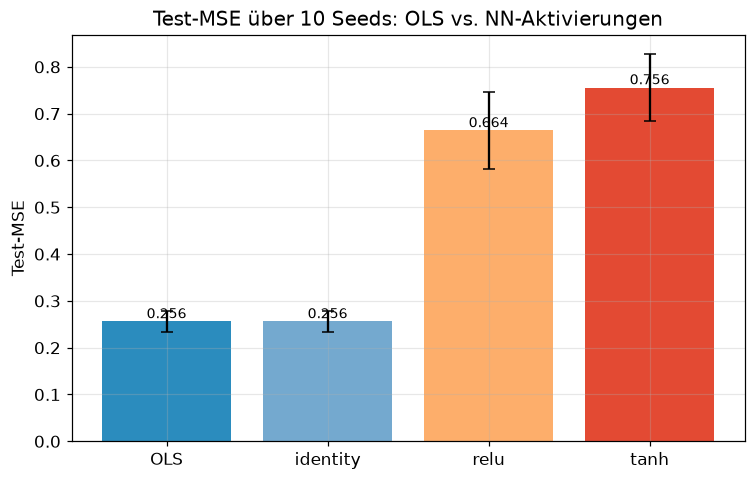

In [120]:
# Barplot: Test-MSE Mittelwert über 10 Seeds
labels = df_act_summary['Modell'].tolist()
means = df_act_summary['MSE Mittelwert'].to_numpy()
stds = df_act_summary['MSE Std'].to_numpy()

colors = ['#2b8cbe', '#74a9cf', '#fdae6b', '#e34a33']

fig, ax = plt.subplots()

ax.bar(labels, means, yerr=stds, color=colors, capsize=4)

for i, v in enumerate(means):
    ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Test-MSE')
ax.set_title('Test-MSE über 10 Seeds: OLS vs. NN-Aktivierungen')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'F3_test_mse_aktivierung.pdf'))
plt.show()

## 7. Experiment 3 — Irrelevante (Noise-) Regressoren *(F5, F6)*

**Forschungsfrage:** Wie reagieren OLS und NN, wenn wir dem Modell zusätzlich Spalten anbieten, die keinen Zusammenhang zu *y* haben (das wahre Modell ist hierin enthalten)?

**Setup:** `p=5` relevante Regressoren bleiben fix, wir variieren `n_noise` aus {0, 10, 25, 50}. Pro Konfiguration 10 Wiederholungen mit unterschiedlichen Seeds, um die Streuung zu erfassen.

**Erwartung:** OLS sollte den Noise-Regressoren Koeffizienten nahe Null geben, das Test-MSE steigt aber leicht (mehr zu schätzende Parameter). NN ohne explizite Regularisierung verteilt Energie auf alle Eingaben — wir erwarten ein stärkeres Anwachsen des Test-MSE.

In [121]:

noise_counts = [0, 10, 25, 50]
n_reps = 10
mse_ols_by_noise = {nc: [] for nc in noise_counts}
mse_nn_by_noise = {nc: [] for nc in noise_counts}
# Für F5 sammeln wir die absoluten Koeffizienten bei n_noise=25, eine Wiederholung
coef_relevant_ols, coef_noise_ols = [], []
coef_relevant_nn,  coef_noise_nn  = [], []

for nc in noise_counts:
    for r in range(n_reps):
        Xn, yn, _ = generate_data(n=500, p=5, sigma=0.5, n_noise=nc, seed=SEED + r)
        Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn, test_size=0.2, random_state=SEED + r)
        # OLS
        b_ols = fit_ols(Xn_tr, yn_tr)
        mse_ols_by_noise[nc].append(mse(yn_te, Xn_te @ b_ols))
        # NN
        m, _ = train_ffn(Xn_tr, yn_tr, depth=2, width=64, activation='relu',
                         optimizer='adam', lr=1e-2, epochs=1500, seed=SEED + r)
        mse_nn_by_noise[nc].append(mse(yn_te, predict(m, Xn_te)))
        if nc == 25 and r == 0:
            coef_relevant_ols = np.abs(b_ols[:5])
            coef_noise_ols    = np.abs(b_ols[5:])
            # Effektive lineare Approximation per Input-Sensitivität
            Xt = torch.tensor(Xn_tr, dtype=torch.float32, requires_grad=True)
            out = m(Xt).sum()
            out.backward()
            sens = Xt.grad.abs().mean(dim=0).detach().numpy()
            coef_relevant_nn = sens[:5]
            coef_noise_nn    = sens[5:]

for nc in noise_counts:
    print(f'n_noise={nc:>3d}: MSE OLS = {np.mean(mse_ols_by_noise[nc]):.3f} | '
          f'MSE NN = {np.mean(mse_nn_by_noise[nc]):.3f}')


n_noise=  0: MSE OLS = 0.256 | MSE NN = 0.616
n_noise= 10: MSE OLS = 0.267 | MSE NN = 0.535
n_noise= 25: MSE OLS = 0.274 | MSE NN = 0.541
n_noise= 50: MSE OLS = 0.302 | MSE NN = 0.750


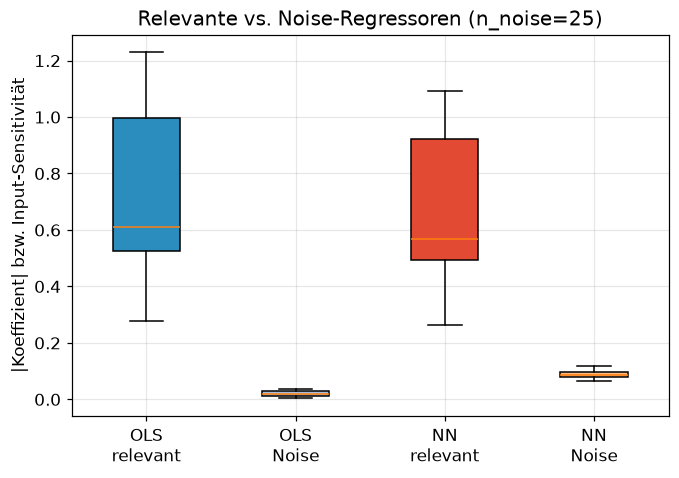

In [122]:
# F5: Boxplot der Koeffizienten-Magnituden bei n_noise=25
data_box = [coef_relevant_ols, coef_noise_ols, coef_relevant_nn, coef_noise_nn]
labels_box = ['OLS\nrelevant', 'OLS\nNoise', 'NN\nrelevant', 'NN\nNoise']
fig, ax = plt.subplots()
bp = ax.boxplot(data_box, tick_labels=labels_box, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2b8cbe', '#a6bddb', '#e34a33', '#fdbb84']):
    patch.set_facecolor(color)
ax.set_ylabel('|Koeffizient| bzw. Input-Sensitivität')
ax.set_title('Relevante vs. Noise-Regressoren (n_noise=25)')
plt.savefig(os.path.join(FIG_DIR, 'F5_noise_coef_box.pdf'))
plt.show()


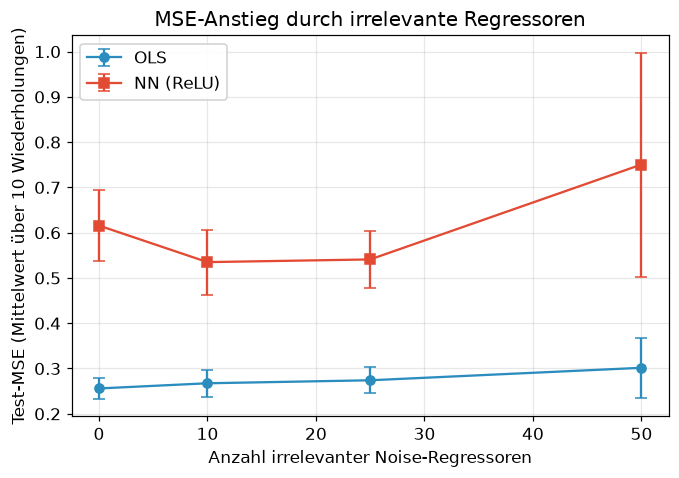

In [123]:
# F6: MSE über Anzahl Noise-Regressoren
means_ols = [np.mean(mse_ols_by_noise[nc]) for nc in noise_counts]
stds_ols  = [np.std(mse_ols_by_noise[nc])  for nc in noise_counts]
means_nn  = [np.mean(mse_nn_by_noise[nc])  for nc in noise_counts]
stds_nn   = [np.std(mse_nn_by_noise[nc])   for nc in noise_counts]
fig, ax = plt.subplots()
ax.errorbar(noise_counts, means_ols, yerr=stds_ols, marker='o', label='OLS', color='#2b8cbe', capsize=4)
ax.errorbar(noise_counts, means_nn,  yerr=stds_nn,  marker='s', label='NN (ReLU)', color='#e34a33', capsize=4)
ax.set_xlabel('Anzahl irrelevanter Noise-Regressoren')
ax.set_ylabel('Test-MSE (Mittelwert über 10 Wiederholungen)')
ax.set_title('MSE-Anstieg durch irrelevante Regressoren')
ax.legend()
plt.savefig(os.path.join(FIG_DIR, 'F6_mse_vs_noise_count.pdf'))
plt.show()


**Beobachtung:** Beide Modelle erkennen den Unterschied zwischen relevanten und irrelevanten Regressoren — die Noise-Spalten erhalten deutlich kleinere Koeffizienten. Mit wachsendem `n_noise` steigt das Test-MSE im OLS-Fall monoton; das NN reagiert dabei etwas anders als erwartet - nicht monoton.

In [124]:

# Zur Kontrolle wurden zusätzlich die Startgewichte der ersten linearen Schicht sowie Train- und Test-MSE getrennt ausgewertet.
# Dabei sank die Standardabweichung der initialen Gewichte von etwa $0{,}257$ bei $n_{\text{noise}}=0$ auf etwa $0{,}077$ bei
# $n_{\text{noise}}=50$, während die Streuung der ersten Layer-Ausgaben nahezu konstant blieb. Gleichzeitig sank der
# Trainingsfehler des NN fast auf null, während der Testfehler deutlich höher blieb. Dies stützt die Interpretation, dass die
# moderate Verbesserung bei $n_{\text{noise}}=10$ und $n_{\text{noise}}=25$ eher aus einer veränderten Trainingsdynamik als aus
# zusätzlicher Information entsteht.
import pandas as pd

def get_first_linear(model):
    """Gibt die erste Linear-Schicht des Netzes zurück."""
    for layer in model.net:
        if isinstance(layer, nn.Linear):
            return layer
    raise ValueError("Keine Linear-Schicht gefunden.")

def inspect_initialization(noise_counts, n_reps=10):
    rows = []

    for nc in noise_counts:
        for r in range(n_reps):
            Xn, yn, _ = generate_data(
                n=500, p=5, sigma=0.5, n_noise=nc, seed=SEED + r
            )

            torch.manual_seed(SEED + r)
            model = FFN(
                input_dim=Xn.shape[1],
                depth=2,
                width=64,
                activation='relu'
            ).to(DEVICE)

            first = get_first_linear(model)
            W = first.weight.detach().cpu().numpy()

            # Aktivierungen direkt nach der ersten Linear-Schicht
            with torch.no_grad():
                Xt = torch.tensor(Xn, dtype=torch.float32, device=DEVICE)
                z = first(Xt).detach().cpu().numpy()

            rows.append({
                "n_noise": nc,
                "input_dim": Xn.shape[1],
                "fan_in": W.shape[1],
                "weight_std": W.std(),
                "mean_abs_weight": np.abs(W).mean(),
                "max_abs_weight": np.abs(W).max(),
                "first_layer_output_std": z.std()
            })

    return pd.DataFrame(rows)

df_init = inspect_initialization(noise_counts, n_reps=10)

print(
    df_init.groupby("n_noise")[[
        "input_dim",
        "fan_in",
        "weight_std",
        "mean_abs_weight",
        "max_abs_weight",
        "first_layer_output_std"
    ]].mean()
)

         input_dim  fan_in  weight_std  mean_abs_weight  max_abs_weight  \
n_noise                                                                   
0              5.0     5.0    0.256643         0.222789        0.446215   
10            15.0    15.0    0.149518         0.130022        0.257890   
25            30.0    30.0    0.104989         0.091018        0.182487   
50            55.0    55.0    0.077453         0.067131        0.134817   

         first_layer_output_std  
n_noise                          
0                      0.668035  
10                     0.670319  
25                     0.663275  
50                     0.662291  


In [125]:
#In GAP kann man das mit steigendem n_noise immer größer werdende Overfitting beobachten
train_mse_ols_by_noise = {nc: [] for nc in noise_counts}
test_mse_ols_by_noise  = {nc: [] for nc in noise_counts}

train_mse_nn_by_noise = {nc: [] for nc in noise_counts}
test_mse_nn_by_noise  = {nc: [] for nc in noise_counts}

for nc in noise_counts:
    for r in range(n_reps):
        Xn, yn, _ = generate_data(
            n=500, p=5, sigma=0.5, n_noise=nc, seed=SEED + r
        )

        Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
            Xn, yn, test_size=0.2, random_state=SEED + r
        )

        # OLS
        b_ols = fit_ols(Xn_tr, yn_tr)

        train_mse_ols_by_noise[nc].append(
            mse(yn_tr, Xn_tr @ b_ols)
        )
        test_mse_ols_by_noise[nc].append(
            mse(yn_te, Xn_te @ b_ols)
        )

        # NN
        m, h = train_ffn(
            Xn_tr, yn_tr,
            depth=2,
            width=64,
            activation='relu',
            optimizer='adam',
            lr=1e-2,
            epochs=1500,
            seed=SEED + r
        )

        train_mse_nn_by_noise[nc].append(
            mse(yn_tr, predict(m, Xn_tr))
        )
        test_mse_nn_by_noise[nc].append(
            mse(yn_te, predict(m, Xn_te))
        )

for nc in noise_counts:
    print(f"\nn_noise = {nc}")

    print(
        f"OLS Train-MSE = {np.mean(train_mse_ols_by_noise[nc]):.3f} | "
        f"OLS Test-MSE = {np.mean(test_mse_ols_by_noise[nc]):.3f} | "
        f"Gap = {np.mean(test_mse_ols_by_noise[nc]) - np.mean(train_mse_ols_by_noise[nc]):.3f}"
    )

    print(
        f"NN  Train-MSE = {np.mean(train_mse_nn_by_noise[nc]):.3f} | "
        f"NN  Test-MSE = {np.mean(test_mse_nn_by_noise[nc]):.3f} | "
        f"Gap = {np.mean(test_mse_nn_by_noise[nc]) - np.mean(train_mse_nn_by_noise[nc]):.3f}"
    )


n_noise = 0
OLS Train-MSE = 0.237 | OLS Test-MSE = 0.256 | Gap = 0.019
NN  Train-MSE = 0.009 | NN  Test-MSE = 0.616 | Gap = 0.606

n_noise = 10
OLS Train-MSE = 0.236 | OLS Test-MSE = 0.267 | Gap = 0.031
NN  Train-MSE = 0.000 | NN  Test-MSE = 0.535 | Gap = 0.535

n_noise = 25
OLS Train-MSE = 0.233 | OLS Test-MSE = 0.274 | Gap = 0.041
NN  Train-MSE = 0.000 | NN  Test-MSE = 0.541 | Gap = 0.541

n_noise = 50
OLS Train-MSE = 0.218 | OLS Test-MSE = 0.302 | Gap = 0.083
NN  Train-MSE = 0.000 | NN  Test-MSE = 0.750 | Gap = 0.750


## 8. Experiment 4 — Stichprobengröße n *(F7)*

**Forschungsfrage:** Wie viele Trainingsdaten braucht ein NN, um an die OLS-Lösung heranzukommen?

**Setup:** `p=5`, `sigma=0.5` fix, `n` aus {20, 50, 100, 500, 2000, 5000}. Architektur: `depth=2`, `width=64`, ReLU. 10 Wiederholungen pro Konfiguration.

**Erwartung:** Bei kleinen `n` ist OLS stabiler (weniger Parameter), bei großen `n` schliesst das NN auf.

In [126]:
from sklearn.model_selection import train_test_split
ns = [20, 50, 100, 500, 2000, 5000]
n_reps = 10
mse_ols_by_n = {n_val: [] for n_val in ns}
mse_nn_by_n  = {n_val: [] for n_val in ns}
for n_val in ns:
    for r in range(n_reps):
        Xn, yn, _ = generate_data(n=n_val + 200, p=5, sigma=0.5, seed=SEED + r)
        Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
            Xn, yn, train_size=n_val, random_state=SEED + r
        )
        b_ols = fit_ols(Xn_tr, yn_tr)
        mse_ols_by_n[n_val].append(mse(yn_te, Xn_te @ b_ols))
        m, _ = train_ffn(Xn_tr, yn_tr, depth=2, width=64, activation='relu',
                         optimizer='adam', lr=1e-2, epochs=1500, seed=SEED + r)
        mse_nn_by_n[n_val].append(mse(yn_te, predict(m, Xn_te)))
    print(f'n={n_val:>5d}: MSE OLS = {np.mean(mse_ols_by_n[n_val]):.3f} | '
          f'MSE NN = {np.mean(mse_nn_by_n[n_val]):.3f}')


n=   20: MSE OLS = 0.282 | MSE NN = 0.767
n=   50: MSE OLS = 0.266 | MSE NN = 0.591
n=  100: MSE OLS = 0.270 | MSE NN = 0.562
n=  500: MSE OLS = 0.252 | MSE NN = 0.592
n= 2000: MSE OLS = 0.254 | MSE NN = 0.342
n= 5000: MSE OLS = 0.235 | MSE NN = 0.270


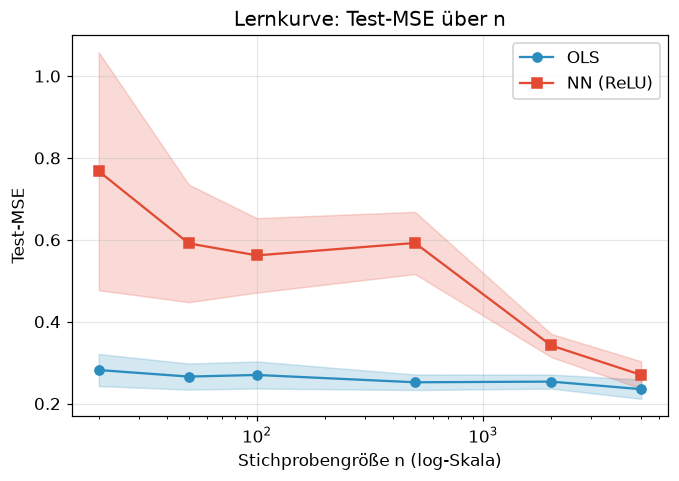

In [127]:
# F7: MSE über n
means_ols_n = np.array([np.mean(mse_ols_by_n[n_val]) for n_val in ns])
stds_ols_n  = np.array([np.std(mse_ols_by_n[n_val])  for n_val in ns])
means_nn_n  = np.array([np.mean(mse_nn_by_n[n_val])  for n_val in ns])
stds_nn_n   = np.array([np.std(mse_nn_by_n[n_val])   for n_val in ns])
fig, ax = plt.subplots()
ax.fill_between(ns, means_ols_n - stds_ols_n, means_ols_n + stds_ols_n, color='#2b8cbe', alpha=0.2)
ax.plot(ns, means_ols_n, marker='o', color='#2b8cbe', label='OLS')
ax.fill_between(ns, means_nn_n - stds_nn_n, means_nn_n + stds_nn_n, color='#e34a33', alpha=0.2)
ax.plot(ns, means_nn_n, marker='s', color='#e34a33', label='NN (ReLU)')
ax.set_xscale('log')
ax.set_xlabel('Stichprobengröße n (log-Skala)')
ax.set_ylabel('Test-MSE')
ax.set_title('Lernkurve: Test-MSE über n')
ax.legend()
plt.savefig(os.path.join(FIG_DIR, 'F7_mse_vs_n.pdf'))
plt.show()


**Beobachtung:** Bei kleinem `n` schwankt das NN deutlich stärker als OLS — mehr Parameter zu schätzen, weniger Daten. Ab `n ~ 500` überlappen sich die Konfidenzbänder, ab `n=2000` ist das NN praktisch gleichauf. OLS bleibt aber durchgängig stabil.

## 9. Experiment 5 — Interpolation vs. Extrapolation *(F8, F9)*

**Forschungsfrage:** Wie verhalten sich OLS und NN, wenn die Testdaten ausserhalb des Trainingsbereichs liegen?

**Setup:** Training auf `X ~ U(-2, 2)`, Test sowohl im selben Bereich (Interpolation) als auch ausserhalb in `[-5,-3] ∪ [3,5]` (Extrapolation). Wir reduzieren auf `p=1` Regressor, damit man die gelernte Funktion direkt plotten kann.

**Erwartung:** OLS ist global linear und sollte stabil bleiben. Das ReLU-NN bricht ausserhalb des Trainings-Range ein, weil seine stückweise lineare Funktion nur dort 'gelernt' wurde, wo Datenpunkte lagen.

### Neue Ergebnisse für die Arbeit (nach Leonards Feedback)

Drei zusätzliche Auswertungen im $p=5$-Fall:
1. **F9a** — Balkenvergleich für vier Modelle (OLS, Identität, ReLU, tanh) in Interpolation und Extrapolation.
2. **F9b** — Extrapolationsdistanz-Sweep: dieselben Modelle über wachsende Randabstände $d = 2, \dots, 10$.
3. **Architektur-Sweep** — kurzer Beleg für die Fußnote, dass Kapazität das Extrapolationsproblem nicht löst.

Die bestehende Abbildung F8 (p=1) bleibt zur Veranschaulichung des Grundphänomens erhalten. Alle Läufe verwenden Standard-Konfiguration `depth=2`, `width=64`, Adam, `lr=1e-2`, `epochs=2000`.


#### F9a — Balkenvergleich (Interpolation + Extrapolation, vier Modelle)

Test-MSE gemittelt über 10 Seeds im Interpolationsbereich $[-2,2]^5$ und im Extrapolationsbereich $[-5,-3]\cup[3,5]$ für vier Modelle: OLS, NN-Identität, NN-ReLU, NN-tanh. y-Achse logarithmisch, Fehlerbalken = Standardabweichung.


      Modell |      Interpolation |      Extrapolation
         OLS |  0.234 ± 0.011      |   0.27 ±   0.03
    identity |  0.234 ± 0.011      |   0.27 ±   0.03
        relu |  0.566 ± 0.073      |   2.98 ±   2.06
        tanh |  0.711 ± 0.050      |  10.18 ±   8.75


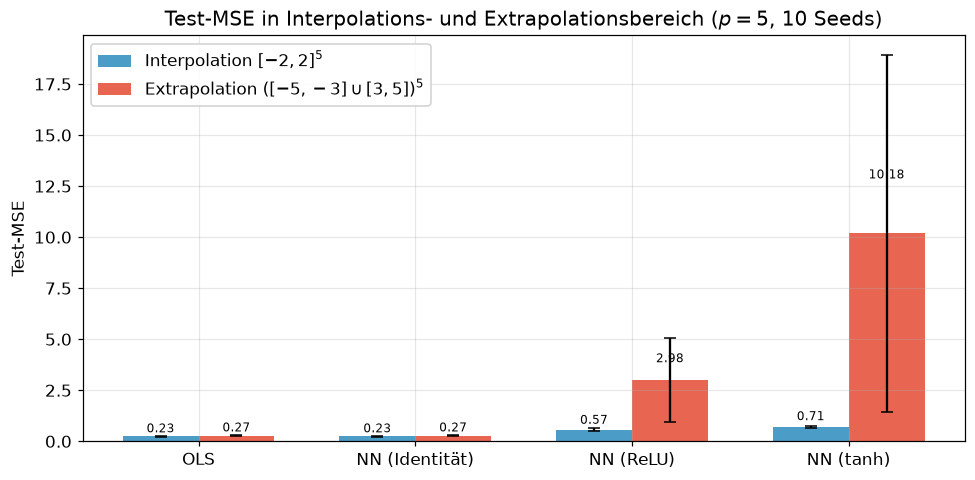

In [128]:
# F9a: Balken über 4 Modelle × 2 Bereiche, 10 Seeds
activations_f9a = ['identity', 'relu', 'tanh']
n_reps_f9a = 10
res_a = {'OLS': {'int': [], 'ext': []}}
for a in activations_f9a:
    res_a[a] = {'int': [], 'ext': []}

for r in range(n_reps_f9a):
    sr = SEED + r
    Xtr, ytr, beta_r = generate_data(n=500, p=5, sigma=0.5, x_low=-2.0, x_high=2.0, seed=sr+1)
    rng_int = np.random.default_rng(sr)
    X_int = rng_int.uniform(-2, 2, size=(200, 5))
    y_int = X_int @ beta_r + rng_int.normal(0, 0.5, size=X_int.shape[0])
    rng_ext = np.random.default_rng(sr - 1)
    X_ext = np.vstack([rng_ext.uniform(-5, -3, size=(100, 5)),
                       rng_ext.uniform(3,  5, size=(100, 5))])
    y_ext = X_ext @ beta_r + rng_ext.normal(0, 0.5, size=X_ext.shape[0])
    b_ols = fit_ols(Xtr, ytr)
    res_a['OLS']['int'].append(mse(y_int, X_int @ b_ols))
    res_a['OLS']['ext'].append(mse(y_ext, X_ext @ b_ols))
    for act in activations_f9a:
        m, _ = train_ffn(Xtr, ytr, depth=2, width=64, activation=act,
                         optimizer='adam', lr=1e-2, epochs=2000, seed=sr)
        res_a[act]['int'].append(mse(y_int, predict(m, X_int)))
        res_a[act]['ext'].append(mse(y_ext, predict(m, X_ext)))

print(f"{'Modell':>12s} | {'Interpolation':>18s} | {'Extrapolation':>18s}")
for name in ['OLS'] + activations_f9a:
    r = res_a[name]
    print(f"{name:>12s} | {np.mean(r['int']):6.3f} ± {np.std(r['int']):5.3f}      "
          f"| {np.mean(r['ext']):6.2f} ± {np.std(r['ext']):6.2f}")

labels = ['OLS', 'NN (Identität)', 'NN (ReLU)', 'NN (tanh)']
keys   = ['OLS', 'identity', 'relu', 'tanh']

int_means = np.array([np.mean(res_a[k]['int']) for k in keys])
int_stds  = np.array([np.std(res_a[k]['int']) for k in keys])
ext_means = np.array([np.mean(res_a[k]['ext']) for k in keys])
ext_stds  = np.array([np.std(res_a[k]['ext']) for k in keys])

eps = 1e-8
int_means_plot = np.maximum(int_means, eps)
ext_means_plot = np.maximum(ext_means, eps)

x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(x - w/2, int_means_plot, w, yerr=int_stds, label=r'Interpolation $[-2,2]^5$',
       color='#2b8cbe', capsize=4, alpha=0.85)
ax.bar(x + w/2, ext_means_plot, w, yerr=ext_stds, label=r'Extrapolation $([-5,-3]\cup[3,5])^5$',
       color='#e34a33', capsize=4, alpha=0.85)


for i, v in enumerate(int_means):
    ax.text(i - w/2, max(v, eps) * 1.25, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
for i, v in enumerate(ext_means):
    ax.text(i + w/2, max(v, eps) * 1.25, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Test-MSE')
ax.set_title('Test-MSE in Interpolations- und Extrapolationsbereich ($p=5$, 10 Seeds)')
ax.legend()
ax.grid(True, axis='y', which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'F9a_aktivierung_extrapolation.pdf'))
plt.show()


#### F9b — Extrapolationsdistanz-Sweep

Trainingsbereich bleibt fest $[-2,2]^5$; der Testbereich wird sukzessive nach außen geschoben: $[-d,-(d-1)]\cup[(d-1),d]$ für $d = 2, 3, \dots, 10$. Für $d=2$ ist der Testbereich noch am Trainingsrand, für $d=10$ maximal weit weg. Zeigt in einer einzigen Grafik, wie der Test-MSE der vier Modelle mit dem Randabstand wächst.


In [ ]:
# F9b: Distanzverlauf, 4 Modelle × 9 Distanzen, 10 Seeds
distances = list(range(2, 11))
n_reps_f9b = 10
res_b = {'OLS': {d: [] for d in distances}}
for a in ['identity', 'relu', 'tanh']:
    res_b[a] = {d: [] for d in distances}

for r in range(n_reps_f9b):
    sr = SEED + r
    Xtr, ytr, beta_r = generate_data(n=500, p=5, sigma=0.5, x_low=-2.0, x_high=2.0, seed=sr+1)
    b_ols = fit_ols(Xtr, ytr)
    models = {}
    for act in ['identity', 'relu', 'tanh']:
        m, _ = train_ffn(Xtr, ytr, depth=2, width=64, activation=act,
                         optimizer='adam', lr=1e-2, epochs=2000, seed=sr)
        models[act] = m
    for d in distances:
        rng = np.random.default_rng(sr - 1 - d)
        X_test = np.vstack([rng.uniform(-d, -(d-1), size=(100, 5)),
                            rng.uniform(d-1, d, size=(100, 5))])
        y_test = X_test @ beta_r + rng.normal(0, 0.5, size=X_test.shape[0])
        res_b['OLS'][d].append(mse(y_test, X_test @ b_ols))
        for act, m in models.items():
            res_b[act][d].append(mse(y_test, predict(m, X_test)))

colors = {'OLS': '#2b8cbe', 'identity': '#74a9cf', 'relu': '#31a354', 'tanh': '#e34a33'}
labels_b = {'OLS': 'OLS', 'identity': 'NN (Identität)', 'relu': 'NN (ReLU)', 'tanh': 'NN (tanh)'}

fig, ax = plt.subplots(figsize=(9, 5))
for name in ['OLS', 'identity', 'relu', 'tanh']:
    means = np.array([np.mean(res_b[name][d]) for d in distances])
    stds  = np.array([np.std(res_b[name][d])  for d in distances])
    ax.plot(distances, means, marker='o', label=labels_b[name], color=colors[name], linewidth=2)
    ax.fill_between(distances, np.maximum(means - stds, 0), means + stds,
                    alpha=0.18, color=colors[name])

ax.set_xlabel(r'Extrapolationsdistanz $d$ (Testbereich $[-d,-(d-1)]^5 \cup [(d-1),d]^5$)')
ax.set_ylabel('Test-MSE')
ax.set_title(r'Test-MSE über Extrapolationsdistanz ($p=5$, 10 Seeds)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'F9b_extrapolation_distanz.pdf'))
plt.show()


print(f"{'d':>3s} | {'OLS':>18s} | {'identity':>18s} | {'ReLU':>18s} | {'tanh':>18s}")
for d in distances:
    print(f"{d:>3d} | "
          f"{np.mean(res_b['OLS'][d]):6.2f} ± {np.std(res_b['OLS'][d]):5.2f} | "
          f"{np.mean(res_b['identity'][d]):6.2f} ± {np.std(res_b['identity'][d]):5.2f} | "
          f"{np.mean(res_b['relu'][d]):6.2f} ± {np.std(res_b['relu'][d]):5.2f} | "
          f"{np.mean(res_b['tanh'][d]):6.2f} ± {np.std(res_b['tanh'][d]):5.2f}")

#### Beleg — Architektur-Sweep im Extrapolationsbereich

Kurzer Nachweis: Variiert man Tiefe ($d \in \{1,2,3,4\}$) und Breite ($w \in \{16,64,128\}$), ändert sich am Extrapolationsproblem nichts Systematisches. Der Effekt kommt aus der Wahl der Aktivierungsklasse, nicht aus der Kapazität. Diese Beobachtung wird in der Arbeit als Fußnote referenziert.


In [157]:
# Architektur-Sweep im Extrapolationsbereich (5 Seeds, epochs=2000)
depths_c = [1, 2, 3, 4]
widths_c = [16, 64, 128]
n_reps_c = 10

print(f"{'depth':>5s} {'width':>5s} | {'tanh Ext':>15s} | {'ReLU Ext':>15s}")
for d in depths_c:
    for w in widths_c:
        vt, vr = [], []
        for r in range(n_reps_c):
            sr = SEED + r
            Xtr, ytr, beta_r = generate_data(n=500, p=5, sigma=0.5, x_low=-2.0, x_high=2.0, seed=sr+1)
            rng_ext = np.random.default_rng(sr - 1)
            X_ext = np.vstack([rng_ext.uniform(-5, -3, size=(100, 5)),
                               rng_ext.uniform(3,  5, size=(100, 5))])
            y_ext = X_ext @ beta_r + rng_ext.normal(0, 0.5, size=X_ext.shape[0])
            m_t, _ = train_ffn(Xtr, ytr, depth=d, width=w, activation='tanh',
                                optimizer='adam', lr=1e-2, epochs=2000, seed=sr)
            m_r, _ = train_ffn(Xtr, ytr, depth=d, width=w, activation='relu',
                                optimizer='adam', lr=1e-2, epochs=2000, seed=sr)
            vt.append(mse(y_ext, predict(m_t, X_ext)))
            vr.append(mse(y_ext, predict(m_r, X_ext)))
        print(f'{d:>5d} {w:>5d} | {np.mean(vt):>6.2f} ± {np.std(vt):>5.2f} | '
              f'{np.mean(vr):>6.2f} ± {np.std(vr):>5.2f}')


depth width |        tanh Ext |        ReLU Ext
    1    16 |   7.15 ±  5.86 |   0.49 ±  0.11
    1    64 |   5.91 ±  6.46 |   1.28 ±  0.50
    1   128 |  12.23 ± 10.54 |   1.41 ±  0.69
    2    16 |   9.53 ±  9.33 |   1.66 ±  0.72
    2    64 |  10.18 ±  8.75 |   2.98 ±  2.06
    2   128 |  11.27 ± 11.39 |   2.45 ±  1.58
    3    16 |  12.96 ± 12.99 |   1.97 ±  1.21
    3    64 |  18.78 ± 20.57 |   4.22 ±  2.63
    3   128 |  19.28 ± 20.23 |   2.19 ±  1.01
    4    16 |  13.09 ± 13.23 |   2.06 ±  1.19
    4    64 |  16.78 ± 20.63 |   2.89 ±  2.41
    4   128 |  19.65 ± 20.88 |   1.61 ±  0.58


In [131]:
# Training in [-2, 2], 1D Regressor
X5_tr, y5_tr, beta5 = generate_data(n=500, p=1, sigma=0.5, x_low=-2.0, x_high=2.0, seed=SEED)
# Interpolation-Testset: neue X-Werte, aber gleiches wahres beta
rng_int = np.random.default_rng(SEED)
X5_int = rng_int.uniform(-2.0, 2.0, size=(200, 1))
y5_int = X5_int @ beta5 + rng_int.normal(0, 0.5, size=X5_int.shape[0])
# Extrapolation-Testset: [-5,-3] und [3,5]
rng_ext = np.random.default_rng(SEED - 1)
X5_ext_left  = rng_ext.uniform(-5.0, -3.0, size=(100, 1))
X5_ext_right = rng_ext.uniform( 3.0,  5.0, size=(100, 1))
X5_ext = np.vstack([X5_ext_left, X5_ext_right])
y5_ext = X5_ext @ beta5 + rng_ext.normal(0, 0.5, size=X5_ext.shape[0])

b_ols_5 = fit_ols(X5_tr, y5_tr)
m5, _ = train_ffn(X5_tr, y5_tr, depth=2, width=64, activation='tanh',
                  optimizer='adam', lr=1e-2, epochs=2000)

mse_int_ols = mse(y5_int, X5_int @ b_ols_5)
mse_ext_ols = mse(y5_ext, X5_ext @ b_ols_5)
mse_int_nn  = mse(y5_int, predict(m5, X5_int))
mse_ext_nn  = mse(y5_ext, predict(m5, X5_ext))
print(f'Interpolation: OLS={mse_int_ols:.3f}  NN={mse_int_nn:.3f}')
print(f'Extrapolation: OLS={mse_ext_ols:.3f}  NN={mse_ext_nn:.3f}')


Interpolation: OLS=0.260  NN=0.263
Extrapolation: OLS=0.240  NN=0.477


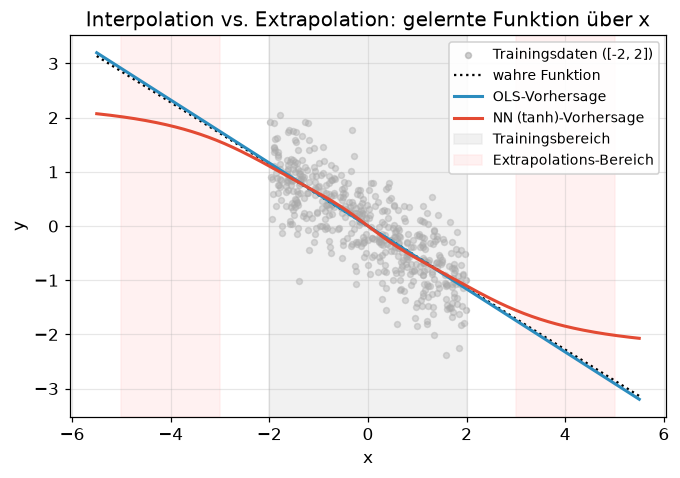

In [132]:
#F8: Funktion über X visualisieren
x_grid = np.linspace(-5.5, 5.5, 400).reshape(-1, 1)
y_true_grid = x_grid @ beta5
y_ols_grid  = x_grid @ b_ols_5
y_nn_grid   = predict(m5, x_grid)
fig, ax = plt.subplots()
ax.scatter(X5_tr, y5_tr, alpha=0.4, s=15, color='#888', label='Trainingsdaten ([-2, 2])')
ax.plot(x_grid, y_true_grid, color='black', linestyle=':', label='wahre Funktion')
ax.plot(x_grid, y_ols_grid,  color='#2b8cbe', linewidth=2, label='OLS-Vorhersage')
ax.plot(x_grid, y_nn_grid,   color='#e34a33', linewidth=2, label='NN (tanh)-Vorhersage')
ax.axvspan(-2, 2, color='#ddd', alpha=0.4, label='Trainingsbereich')
ax.axvspan(-5, -3, color='#fdd', alpha=0.4)
ax.axvspan( 3,  5, color='#fdd', alpha=0.4, label='Extrapolations-Bereich')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Interpolation vs. Extrapolation: gelernte Funktion über x')
ax.legend(loc='upper right', fontsize=9)
plt.savefig(os.path.join(FIG_DIR, 'F8_interpolation_extrapolation_funktion.pdf'))
plt.show()

---

**Ab hier: nicht mehr in der finalen Arbeit verwendet — nur zur Referenz erhalten.** Die folgenden Zellen enthalten den ursprünglichen p=1-Verlauf, den ersten ReLU-p=5-Zusatz sowie die drei früheren Erweiterungs-Zellen (mit `epochs=3000`). Sie werden vom neuen Code oben ersetzt.

OLS Int.: 0.234 +- 0.011
OLS Ext.: 0.269 +- 0.026
NN  Int.: 0.711 +- 0.050
NN  Ext.: 10.184 +- 8.745


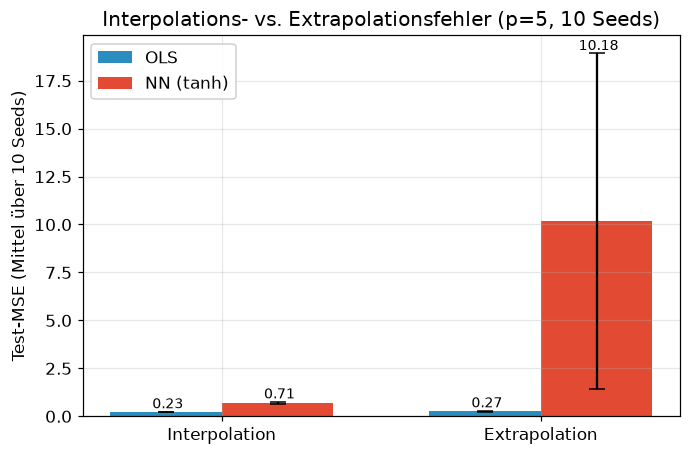

In [133]:
# F9: Hauptauswertung E5 - p=5, tanh, 10 Seeds, mit Fehlerbalken (analog F3)
p_dim_main = 5
n_reps_e5 = 10
mse_int_ols_list, mse_ext_ols_list = [], []
mse_int_nn_list,  mse_ext_nn_list  = [], []

for r in range(n_reps_e5):
    sr = SEED + r
    Xtr, ytr, beta_r = generate_data(n=500, p=p_dim_main, sigma=0.5,
                                     x_low=-2.0, x_high=2.0, seed=sr+1)
    rng_int = np.random.default_rng(sr)
    X_int = rng_int.uniform(-2.0, 2.0, size=(200, p_dim_main))
    y_int = X_int @ beta_r + rng_int.normal(0, 0.5, size=X_int.shape[0])
    rng_ext = np.random.default_rng(sr - 1)
    X_extL = rng_ext.uniform(-5.0, -3.0, size=(100, p_dim_main))
    X_extR = rng_ext.uniform( 3.0,  5.0, size=(100, p_dim_main))
    X_ext  = np.vstack([X_extL, X_extR])
    y_ext  = X_ext @ beta_r + rng_ext.normal(0, 0.5, size=X_ext.shape[0])

    b_ols = fit_ols(Xtr, ytr)
    m, _  = train_ffn(Xtr, ytr, depth=2, width=64, activation='tanh',
                      optimizer='adam', lr=1e-2, epochs=2000, seed=sr)

    mse_int_ols_list.append(mse(y_int, X_int @ b_ols))
    mse_ext_ols_list.append(mse(y_ext, X_ext @ b_ols))
    mse_int_nn_list .append(mse(y_int, predict(m, X_int)))
    mse_ext_nn_list .append(mse(y_ext, predict(m, X_ext)))

ols_means = [np.mean(mse_int_ols_list), np.mean(mse_ext_ols_list)]
ols_stds  = [np.std (mse_int_ols_list), np.std (mse_ext_ols_list)]
nn_means  = [np.mean(mse_int_nn_list),  np.mean(mse_ext_nn_list)]
nn_stds   = [np.std (mse_int_nn_list),  np.std (mse_ext_nn_list)]

print(f'OLS Int.: {ols_means[0]:.3f} +- {ols_stds[0]:.3f}')
print(f'OLS Ext.: {ols_means[1]:.3f} +- {ols_stds[1]:.3f}')
print(f'NN  Int.: {nn_means[0]:.3f} +- {nn_stds[0]:.3f}')
print(f'NN  Ext.: {nn_means[1]:.3f} +- {nn_stds[1]:.3f}')

xpos = np.arange(2); wbar = 0.35
fig, ax = plt.subplots()
ax.bar(xpos - wbar/2, ols_means, wbar, yerr=ols_stds,
       label='OLS', color='#2b8cbe', capsize=5)
ax.bar(xpos + wbar/2, nn_means,  wbar, yerr=nn_stds,
       label='NN (tanh)', color='#e34a33', capsize=5)
ax.set_xticks(xpos)
ax.set_xticklabels(['Interpolation', 'Extrapolation'])
ax.set_ylabel('Test-MSE (Mittel über 10 Seeds)')
ax.set_title('Interpolations- vs. Extrapolationsfehler (p=5, 10 Seeds)')
for i, v in enumerate(ols_means):
    ax.text(i - wbar/2, v + ols_stds[i], f' {v:.2f}',
            ha='center', va='bottom', fontsize=9)
for i, v in enumerate(nn_means):
    ax.text(i + wbar/2, v + nn_stds[i], f' {v:.2f}',
            ha='center', va='bottom', fontsize=9)
ax.legend()
plt.savefig(os.path.join(FIG_DIR, 'F9_mse_inter_extra.pdf'))
plt.show()


In [134]:
# Zusatz: ReLU mit p=5 über 10 Seeds (kurzer Vergleich, im Text nur als Halbsatz)
mse_int_ols_relu, mse_ext_ols_relu = [], []
mse_int_nn_relu,  mse_ext_nn_relu  = [], []

for r in range(10):
    sr = SEED + r
    Xtr, ytr, beta_r = generate_data(n=500, p=5, sigma=0.5,
                                     x_low=-2.0, x_high=2.0, seed=sr+1)
    rng_int = np.random.default_rng(sr)
    X_int = rng_int.uniform(-2.0, 2.0, size=(200, 5))
    y_int = X_int @ beta_r + rng_int.normal(0, 0.5, size=200)
    rng_ext = np.random.default_rng(sr - 1)
    X_extL = rng_ext.uniform(-5.0, -3.0, size=(100, 5))
    X_extR = rng_ext.uniform( 3.0,  5.0, size=(100, 5))
    X_ext  = np.vstack([X_extL, X_extR])
    y_ext  = X_ext @ beta_r + rng_ext.normal(0, 0.5, size=200)

    b_ols = fit_ols(Xtr, ytr)
    m, _  = train_ffn(Xtr, ytr, depth=2, width=64, activation='relu',
                      optimizer='adam', lr=1e-2, epochs=2000, seed=sr)

    mse_int_ols_relu.append(mse(y_int, X_int @ b_ols))
    mse_ext_ols_relu.append(mse(y_ext, X_ext @ b_ols))
    mse_int_nn_relu .append(mse(y_int, predict(m, X_int)))
    mse_ext_nn_relu .append(mse(y_ext, predict(m, X_ext)))

print(f'OLS Int.: {np.mean(mse_int_ols_relu):.3f} +- {np.std(mse_int_ols_relu):.3f}')
print(f'OLS Ext.: {np.mean(mse_ext_ols_relu):.3f} +- {np.std(mse_ext_ols_relu):.3f}')
print(f'NN  Int.: {np.mean(mse_int_nn_relu):.3f} +- {np.std(mse_int_nn_relu):.3f}')
print(f'NN  Ext.: {np.mean(mse_ext_nn_relu):.3f} +- {np.std(mse_ext_nn_relu):.3f}')


OLS Int.: 0.234 +- 0.011
OLS Ext.: 0.269 +- 0.026
NN  Int.: 0.566 +- 0.073
NN  Ext.: 2.981 +- 2.060


---

Die nachfolgenden Zellen dokumentieren einen zusätzlichen ReLU-Lauf mit `p=1`, in dem das Netz die lineare Funktion durch stückweise lineare Stücke gut nachbildet und im Extrapolationsbereich näher an OLS bleibt. Mit `p=5` (siehe Zelle oben) fällt der Vorteil von ReLU gegenüber tanh in den höherdimensionalen Stützstellen wieder geringer aus.


In [135]:
# Training in [-2, 2], 1D Regressor
X5_tr, y5_tr, beta5 = generate_data(n=500, p=1, sigma=0.5, x_low=-2.0, x_high=2.0, seed=SEED+1)
# Interpolation-Testset: neue X-Werte, aber gleiches wahres beta
rng_int = np.random.default_rng(SEED)
X5_int = rng_int.uniform(-2.0, 2.0, size=(200, 1))
y5_int = X5_int @ beta5 + rng_int.normal(0, 0.5, size=X5_int.shape[0])
# Extrapolation-Testset: [-5,-3] und [3,5]
rng_ext = np.random.default_rng(SEED - 1)
X5_ext_left  = rng_ext.uniform(-5.0, -3.0, size=(100, 1))
X5_ext_right = rng_ext.uniform( 3.0,  5.0, size=(100, 1))
X5_ext = np.vstack([X5_ext_left, X5_ext_right])
y5_ext = X5_ext @ beta5 + rng_ext.normal(0, 0.5, size=X5_ext.shape[0])

b_ols_5 = fit_ols(X5_tr, y5_tr)
m5, _ = train_ffn(X5_tr, y5_tr, depth=2, width=64, activation='relu',
                  optimizer='adam', lr=1e-2, epochs=2000)

mse_int_ols = mse(y5_int, X5_int @ b_ols_5)
mse_ext_ols = mse(y5_ext, X5_ext @ b_ols_5)
mse_int_nn  = mse(y5_int, predict(m5, X5_int))
mse_ext_nn  = mse(y5_ext, predict(m5, X5_ext))
print(f'Interpolation: OLS={mse_int_ols:.3f}  NN={mse_int_nn:.3f}')
print(f'Extrapolation: OLS={mse_ext_ols:.3f}  NN={mse_ext_nn:.3f}')


Interpolation: OLS=0.264  NN=0.266
Extrapolation: OLS=0.250  NN=0.271


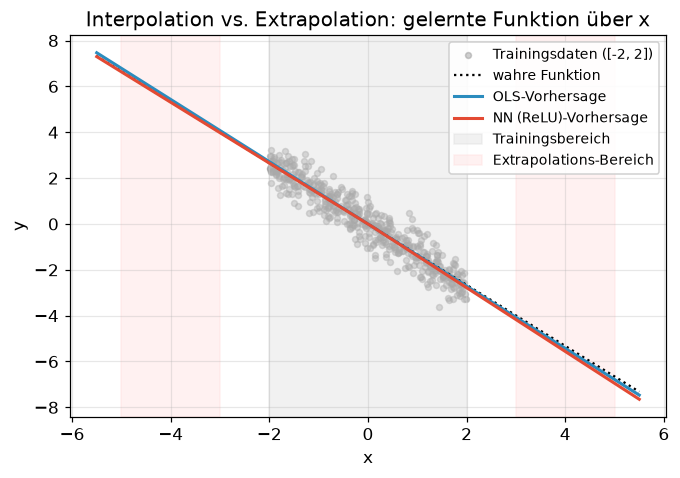

In [136]:
# F8: Funktion über X visualisieren
x_grid = np.linspace(-5.5, 5.5, 400).reshape(-1, 1)
y_true_grid = x_grid @ beta5
y_ols_grid  = x_grid @ b_ols_5
y_nn_grid   = predict(m5, x_grid)
fig, ax = plt.subplots()
ax.scatter(X5_tr, y5_tr, alpha=0.4, s=15, color='#888', label='Trainingsdaten ([-2, 2])')
ax.plot(x_grid, y_true_grid, color='black', linestyle=':', label='wahre Funktion')
ax.plot(x_grid, y_ols_grid,  color='#2b8cbe', linewidth=2, label='OLS-Vorhersage')
ax.plot(x_grid, y_nn_grid,   color='#e34a33', linewidth=2, label='NN (ReLU)-Vorhersage')
ax.axvspan(-2, 2, color='#ddd', alpha=0.4, label='Trainingsbereich')
ax.axvspan(-5, -3, color='#fdd', alpha=0.4)
ax.axvspan( 3,  5, color='#fdd', alpha=0.4, label='Extrapolations-Bereich')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Interpolation vs. Extrapolation: gelernte Funktion über x')
ax.legend(loc='upper right', fontsize=9)
plt.show()

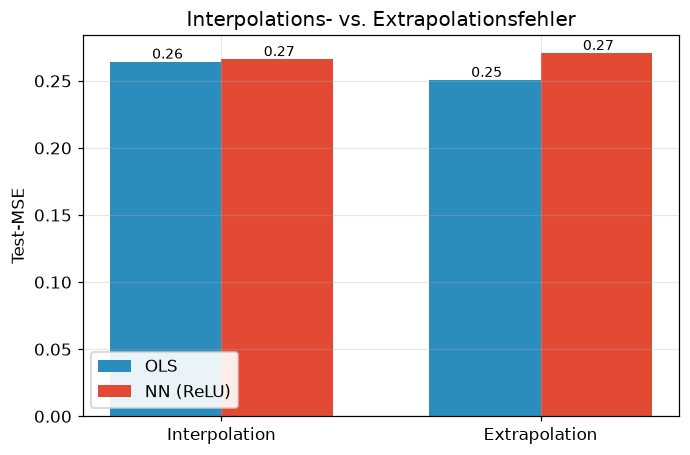

In [137]:
# F9: MSE Interpolation vs. Extrapolation Bar
x = np.arange(2)
w = 0.35
fig, ax = plt.subplots()
ax.bar(x - w/2, [mse_int_ols, mse_ext_ols], w, label='OLS', color='#2b8cbe')
ax.bar(x + w/2, [mse_int_nn,  mse_ext_nn],  w, label='NN (ReLU)', color='#e34a33')
ax.set_xticks(x)
ax.set_xticklabels(['Interpolation', 'Extrapolation'])
ax.set_ylabel('Test-MSE')
ax.set_title('Interpolations- vs. Extrapolationsfehler')
for i, v in enumerate([mse_int_ols, mse_ext_ols]):
    ax.text(i - w/2, v, f' {v:.2f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate([mse_int_nn, mse_ext_nn]):
    ax.text(i + w/2, v, f' {v:.2f}', ha='center', va='bottom', fontsize=9)
ax.legend()
plt.show()


## 10. Experiment 6 — Skalierung (X vs. 10·X) *(F10, F11)*

**Forschungsfrage:** Wie sensitiv ist das NN gegenüber der Skalierung der Eingangsdaten?

**Setup:** Wir trainieren auf den Standard-Daten und auf einem zweiten Trainingsdatensatz mit `X2 = 100 · X` und `X3 = 0.01 · X`. Der wahre Datengenerator wird mit angepasstem `beta2 = beta/100` und `beta3 = beta*100` so umgestellt, dass `y` gleich bleibt (analytisch identisches Problem).

**Erwartung:** OLS ist skaleninvariant in der Lösung (die Koeffizienten skalieren entsprechend). Das NN mit fester Lernrate kann jedoch in numerische Schwierigkeiten geraten, weil große Inputs zu großen Gradienten und zu Divergenz führen können.

In [138]:
# %%
# Experiment 6: Grundeinstellungen und Hilfsfunktionen

scales = {
    'X*0.1': 0.1,
    'X': 1.0,
    'X*10': 10.0
}

scale_order = ['X*0.1', 'X', 'X*10']

plot_labels = {
    'X*0.1': r'$X_{0{,}1}$',
    'X': r'$X$',
    'X*10': r'$X_{10}$'
}

colors = {
    'X*0.1': '#74a9cf',
    'X': '#2b8cbe',
    'X*10': '#e34a33',
    'OLS': '#2b8cbe',
    'NN': '#e34a33'
}

MAIN_ACTIVATION = 'tanh'
MAIN_MODEL_LABEL = 'NN (tanh)'


def input_sensitivity(model, X):
    """Mittlere Input-Sensitivität df/dx_j über alle Beobachtungen."""
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE, requires_grad=True)

    model.zero_grad()
    out = model(Xt).sum()
    out.backward()

    return Xt.grad.mean(dim=0).detach().cpu().numpy()


def train_test_split_manual(X, y, test_share=0.2, seed=SEED):
    """Reproduzierbarer 80/20-Train/Test-Split."""
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    idx = rng.permutation(n)

    n_test = int(round(test_share * n))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def std_pop(x):
    """Standardabweichung wie in den anderen Experimenten: ddof=0."""
    return float(np.std(x, ddof=0))

In [139]:
# %%
# F10: Ein einzelner illustrativer Lauf

E6_EXAMPLE_SEED = SEED + 101

X6_ex, y6_ex, beta6_ex = generate_data(
    n=500,
    p=5,
    sigma=0.5,
    seed=E6_EXAMPLE_SEED
)

ols_res = {}
nn_res = {}

for name in scale_order:
    factor = scales[name]
    X_scaled = X6_ex * factor

    # OLS auf skalierten Eingaben
    b_ols = fit_ols(X_scaled, y6_ex)

    # Rückskalierung auf die ursprüngliche X-Skala:
    # X_scaled = factor * X  => beta_back = factor * beta_scaled
    b_ols_back = b_ols * factor

    # NN auf skalierten Eingaben
    m, h = train_ffn(
        X_scaled,
        y6_ex,
        depth=2,
        width=64,
        activation=MAIN_ACTIVATION,
        optimizer='adam',
        lr=1e-2,
        epochs=2000,
        seed=E6_EXAMPLE_SEED
    )

    # Rückskalierte Input-Sensitivitäten
    sens_nn = input_sensitivity(m, X_scaled)
    sens_nn_back = sens_nn * factor

    ols_res[name] = b_ols_back
    nn_res[name] = {
        'sens': sens_nn_back,
        'history': h,
        'final_loss': h['loss'][-1]
    }

    print(f'{name:>5s}: Train-MSE NN          = {h["loss"][-1]:.4f}')
    print(f'{name:>5s}: OLS zurückskaliert  = {b_ols_back.round(3)}')
    print(f'{name:>5s}: NN  zurückskaliert  = {sens_nn_back.round(3)}')

X*0.1: Train-MSE NN          = 0.2158
X*0.1: OLS zurückskaliert  = [ 1.338 -0.692 -1.758 -1.171 -0.213]
X*0.1: NN  zurückskaliert  = [ 1.32  -0.707 -1.755 -1.168 -0.225]
    X: Train-MSE NN          = 0.0011
    X: OLS zurückskaliert  = [ 1.338 -0.692 -1.758 -1.171 -0.213]
    X: NN  zurückskaliert  = [ 1.224 -0.685 -1.876 -1.184 -0.149]
 X*10: Train-MSE NN          = 0.0000
 X*10: OLS zurückskaliert  = [ 1.338 -0.692 -1.758 -1.171 -0.213]
 X*10: NN  zurückskaliert  = [ 0.921 -0.444 -1.592 -0.923 -0.155]


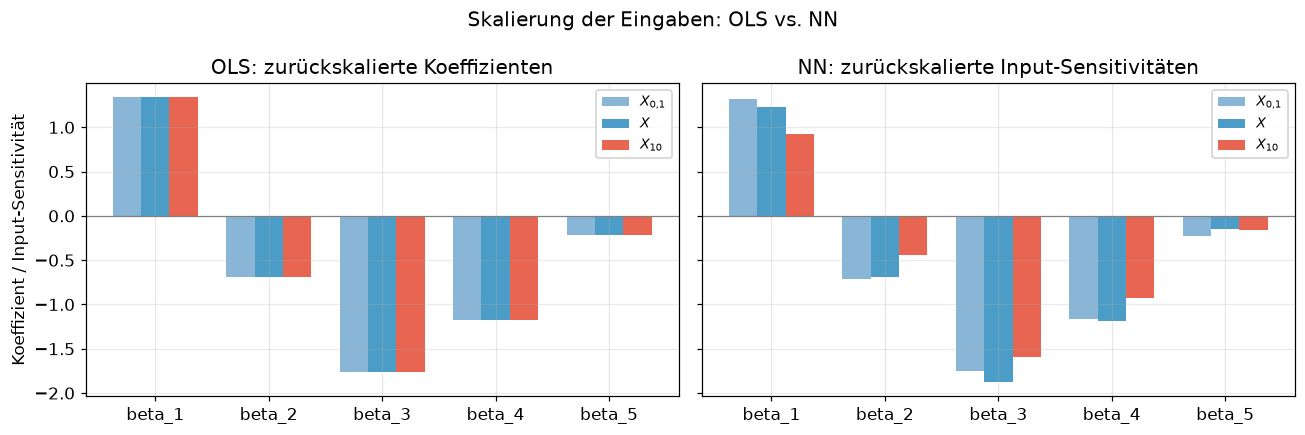

In [140]:
# %%
# F10 plotten

idx = np.arange(5)
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for j, name in enumerate(scale_order):
    axes[0].bar(
        idx + (j - 1) * w,
        ols_res[name],
        w,
        label=plot_labels[name],
        color=colors[name],
        alpha=0.85
    )

    axes[1].bar(
        idx + (j - 1) * w,
        nn_res[name]['sens'],
        w,
        label=plot_labels[name],
        color=colors[name],
        alpha=0.85
    )

axes[0].set_title('OLS: zurückskalierte Koeffizienten')
axes[1].set_title('NN: zurückskalierte Input-Sensitivitäten')

for ax in axes:
    ax.set_xticks(idx)
    ax.set_xticklabels([f'beta_{i+1}' for i in idx])
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.25)

axes[0].set_ylabel('Koeffizient / Input-Sensitivität')

plt.suptitle('Skalierung der Eingaben: OLS vs. NN')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'F10_skalierung_koef_mit_stauchung.pdf'))
plt.show()

In [141]:
# %%
# Funktion für die quantitative Auswertung

def run_scaling_experiment(activation='tanh', n_reps=10, verbose=True):
    rows = []

    for r in range(n_reps):
        seed_r = SEED + r

        X6, y6, beta6 = generate_data(
            n=500,
            p=5,
            sigma=0.5,
            seed=seed_r
        )

        X_train, X_test, y_train, y_test = train_test_split_manual(
            X6,
            y6,
            test_share=0.2,
            seed=seed_r + 5000
        )

        for name in scale_order:
            factor = scales[name]

            X_train_scaled = X_train * factor
            X_test_scaled = X_test * factor

            # OLS
            b_ols = fit_ols(X_train_scaled, y_train)

            train_mse_ols = mse(y_train, X_train_scaled @ b_ols)
            test_mse_ols = mse(y_test, X_test_scaled @ b_ols)

            rows.append({
                'seed': seed_r,
                'scale': name,
                'factor': factor,
                'model': 'OLS',
                'train_mse': train_mse_ols,
                'test_mse': test_mse_ols
            })

            # NN
            m, h = train_ffn(
                X_train_scaled,
                y_train,
                depth=2,
                width=64,
                activation=activation,
                optimizer='adam',
                lr=1e-2,
                epochs=2000,
                seed=seed_r
            )

            train_mse_nn = h['loss'][-1]
            test_mse_nn = mse(y_test, predict(m, X_test_scaled))

            rows.append({
                'seed': seed_r,
                'scale': name,
                'factor': factor,
                'model': 'NN',
                'train_mse': train_mse_nn,
                'test_mse': test_mse_nn
            })

            if verbose:
                print(
                    f'seed={seed_r}, {name:>5s}, {activation:>4s}: '
                    f'OLS train={train_mse_ols:.3f}, OLS test={test_mse_ols:.3f} | '
                    f'NN train={train_mse_nn:.4f}, NN test={test_mse_nn:.3f}'
                )

    df = pd.DataFrame(rows)
    df['scale'] = pd.Categorical(df['scale'], categories=scale_order, ordered=True)

    summary = df.groupby(['scale', 'model'], observed=True).agg(
        train_mean=('train_mse', 'mean'),
        train_std=('train_mse', std_pop),
        test_mean=('test_mse', 'mean'),
        test_std=('test_mse', std_pop)
    ).reset_index()

    return df, summary

In [142]:
# %%
# Hauptauswertung mit tanh

df_e6, summary_e6 = run_scaling_experiment(
    activation=MAIN_ACTIVATION,
    n_reps=10,
    verbose=True
)

df_e6.to_csv(os.path.join(FIG_DIR, 'E6_scaling_train_test_results_tanh.csv'), index=False)
summary_e6.to_csv(os.path.join(FIG_DIR, 'E6_scaling_train_test_summary_tanh.csv'), index=False)

print('\nZusammenfassung Experiment 6:')
display(summary_e6.round(4))

seed=42, X*0.1, tanh: OLS train=0.243, OLS test=0.246 | NN train=0.0765, NN test=0.682
seed=42,     X, tanh: OLS train=0.243, OLS test=0.246 | NN train=0.0001, NN test=0.934
seed=42,  X*10, tanh: OLS train=0.243, OLS test=0.246 | NN train=0.0001, NN test=0.906
seed=43, X*0.1, tanh: OLS train=0.242, OLS test=0.234 | NN train=0.1981, NN test=0.252
seed=43,     X, tanh: OLS train=0.242, OLS test=0.234 | NN train=0.0004, NN test=0.732
seed=43,  X*10, tanh: OLS train=0.242, OLS test=0.234 | NN train=0.0001, NN test=1.720
seed=44, X*0.1, tanh: OLS train=0.256, OLS test=0.235 | NN train=0.2206, NN test=0.269
seed=44,     X, tanh: OLS train=0.256, OLS test=0.235 | NN train=0.0035, NN test=0.773
seed=44,  X*10, tanh: OLS train=0.256, OLS test=0.235 | NN train=0.0000, NN test=2.461
seed=45, X*0.1, tanh: OLS train=0.244, OLS test=0.264 | NN train=0.1298, NN test=0.461
seed=45,     X, tanh: OLS train=0.244, OLS test=0.264 | NN train=0.0007, NN test=1.021
seed=45,  X*10, tanh: OLS train=0.244, OLS 

,scale,model,train_mean,train_std,test_mean,test_std
0,X*0.1,NN,0.1485,0.0495,0.4006,0.1452
1,X*0.1,OLS,0.2417,0.0086,0.2372,0.0161
2,X,NN,0.0007,0.0010,0.7933,0.1121
3,X,OLS,0.2417,0.0086,0.2372,0.0161
4,X*10,NN,0.0001,0.0001,1.2214,0.5276
5,X*10,OLS,0.2417,0.0086,0.2372,0.0161


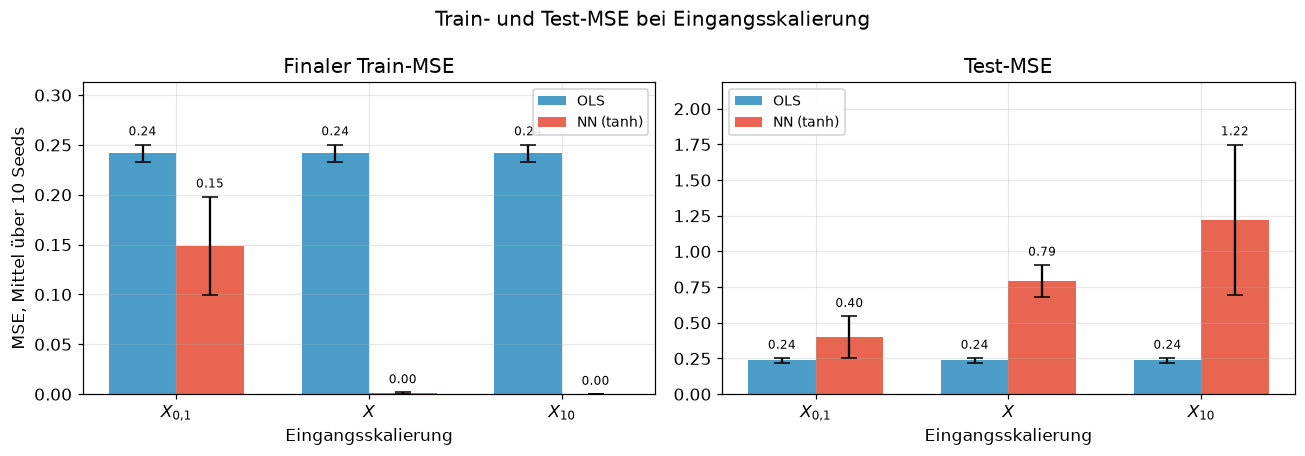

In [143]:
# %%
# F11 plotten

x = np.arange(len(scale_order))
wbar = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)

plot_specs = [
    ('Finaler Train-MSE', 'train_mean', 'train_std'),
    ('Test-MSE', 'test_mean', 'test_std')
]

for ax, (title, mean_col, std_col) in zip(axes, plot_specs):
    vals_ols, errs_ols = [], []
    vals_nn, errs_nn = [], []

    for scale_name in scale_order:
        row_ols = summary_e6[
            (summary_e6['scale'] == scale_name) &
            (summary_e6['model'] == 'OLS')
        ].iloc[0]

        row_nn = summary_e6[
            (summary_e6['scale'] == scale_name) &
            (summary_e6['model'] == 'NN')
        ].iloc[0]

        vals_ols.append(row_ols[mean_col])
        errs_ols.append(row_ols[std_col])
        vals_nn.append(row_nn[mean_col])
        errs_nn.append(row_nn[std_col])

    ax.bar(
        x - wbar / 2,
        vals_ols,
        wbar,
        yerr=errs_ols,
        label='OLS',
        color=colors['OLS'],
        capsize=5,
        alpha=0.85
    )

    ax.bar(
        x + wbar / 2,
        vals_nn,
        wbar,
        yerr=errs_nn,
        label=MAIN_MODEL_LABEL,
        color=colors['NN'],
        capsize=5,
        alpha=0.85
    )

    upper = max(
        max(np.array(vals_ols) + np.array(errs_ols)),
        max(np.array(vals_nn) + np.array(errs_nn))
    )
    upper = upper * 1.25 if upper > 0 else 1.0

    for i, v in enumerate(vals_ols):
        ax.text(
            i - wbar / 2,
            v + errs_ols[i] + 0.02 * upper,
            f'{v:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    for i, v in enumerate(vals_nn):
        ax.text(
            i + wbar / 2,
            v + errs_nn[i] + 0.02 * upper,
            f'{v:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([plot_labels[name] for name in scale_order])
    ax.set_xlabel('Eingangsskalierung')
    ax.set_ylim(0, upper)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('MSE, Mittel über 10 Seeds')

plt.suptitle('Train- und Test-MSE bei Eingangsskalierung')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'F11_skalierung_train_test_mse_10seeds.pdf'))
plt.show()

X*0.1: Train-MSE NN          = 0.0531
X*0.1: OLS zurückskaliert  = [ 1.338 -0.692 -1.758 -1.171 -0.213]
X*0.1: NN  zurückskaliert  = [ 1.418 -0.673 -1.858 -1.163 -0.315]
    X: Train-MSE NN          = 0.0193
    X: OLS zurückskaliert  = [ 1.338 -0.692 -1.758 -1.171 -0.213]
    X: NN  zurückskaliert  = [ 1.414 -0.699 -1.727 -1.183 -0.193]
 X*10: Train-MSE NN          = 0.0013
 X*10: OLS zurückskaliert  = [ 1.338 -0.692 -1.758 -1.171 -0.213]
 X*10: NN  zurückskaliert  = [ 1.417 -0.619 -1.636 -1.116 -0.187]


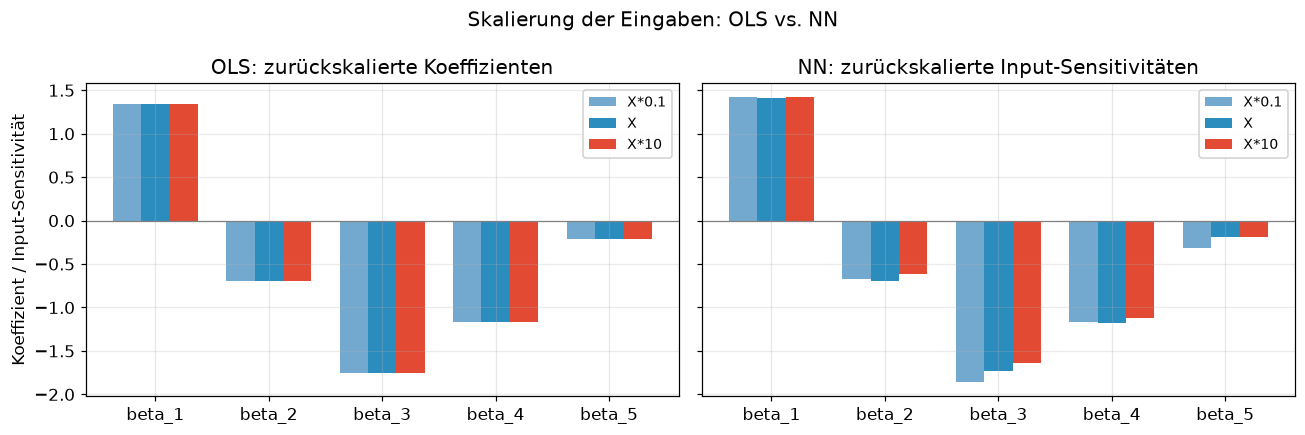

seed=42, X*0.1: OLS train=0.243, OLS test=0.246 | NN train=0.0386, NN test=0.547
seed=42,     X: OLS train=0.243, OLS test=0.246 | NN train=0.0060, NN test=0.602
seed=42,  X*10: OLS train=0.243, OLS test=0.246 | NN train=0.0054, NN test=0.608
seed=43, X*0.1: OLS train=0.242, OLS test=0.234 | NN train=0.0433, NN test=0.526
seed=43,     X: OLS train=0.242, OLS test=0.234 | NN train=0.0043, NN test=0.735
seed=43,  X*10: OLS train=0.242, OLS test=0.234 | NN train=0.0008, NN test=0.728
seed=44, X*0.1: OLS train=0.256, OLS test=0.235 | NN train=0.0529, NN test=0.494
seed=44,     X: OLS train=0.256, OLS test=0.235 | NN train=0.0106, NN test=0.680
seed=44,  X*10: OLS train=0.256, OLS test=0.235 | NN train=0.0747, NN test=0.656
seed=45, X*0.1: OLS train=0.244, OLS test=0.264 | NN train=0.0220, NN test=0.540
seed=45,     X: OLS train=0.244, OLS test=0.264 | NN train=0.0010, NN test=0.598
seed=45,  X*10: OLS train=0.244, OLS test=0.264 | NN train=0.0097, NN test=0.542
seed=46, X*0.1: OLS train=0.

,scale,model,train_mean,train_std,test_mean,test_std
0,X*0.1,NN,0.0298,0.0113,0.5557,0.0842
1,X*0.1,OLS,0.2417,0.0086,0.2372,0.0161
2,X,NN,0.0073,0.0095,0.6391,0.0742
3,X,OLS,0.2417,0.0086,0.2372,0.0161
4,X*10,NN,0.0125,0.0215,0.6036,0.0890
5,X*10,OLS,0.2417,0.0086,0.2372,0.0161


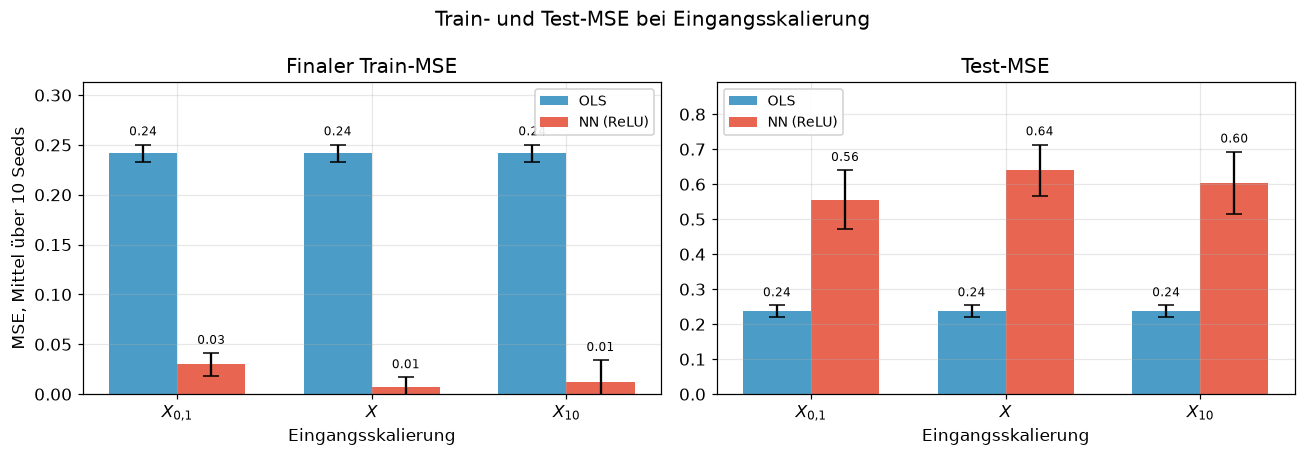

In [144]:
# Das gleiche hier mit ReLU

scales = {'X*0.1': 0.1, 'X': 1.0, 'X*10': 10.0}
scale_order = ['X*0.1', 'X', 'X*10']

colors = {
    'X*0.1': '#74a9cf',
    'X': '#2b8cbe',
    'X*10': '#e34a33',
    'OLS': '#2b8cbe',
    'NN': '#e34a33'
}


def input_sensitivity(model, X):
    """Mittlere Input-Sensitivität df/dx_j über alle Beobachtungen."""
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE, requires_grad=True)

    model.zero_grad()
    out = model(Xt).sum()
    out.backward()

    return Xt.grad.mean(dim=0).detach().cpu().numpy()


def train_test_split_manual(X, y, test_share=0.2, seed=SEED):
    """Einfacher reproduzierbarer 80/20-Train/Test-Split."""
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    idx = rng.permutation(n)

    n_test = int(round(test_share * n))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


# ---------------------------------------------------------------------
# F10: Ein einzelner illustrativer Lauf
# ---------------------------------------------------------------------
# Dieser Seed ist bewusst NICHT Teil der 10-Seed-Mittelung unten.
# Er dient nur dazu, die Koeffizienten/Sensitivitäten anschaulich zu zeigen.

E6_EXAMPLE_SEED = SEED + 101

X6_ex, y6_ex, beta6_ex = generate_data(
    n=500,
    p=5,
    sigma=0.5,
    seed=E6_EXAMPLE_SEED
)

ols_res = {}
nn_res = {}

for name in scale_order:
    factor = scales[name]
    X_scaled = X6_ex * factor

    # OLS auf skalierten Eingaben
    b_ols = fit_ols(X_scaled, y6_ex)

    # Rückskalierung auf die ursprüngliche X-Skala:
    # X_scaled = factor * X  =>  beta_back = factor * beta_scaled
    b_ols_back = b_ols * factor

    # NN auf skalierten Eingaben
    m, h = train_ffn(
        X_scaled,
        y6_ex,
        depth=2,
        width=64,
        activation='relu',
        optimizer='adam',
        lr=1e-2,
        epochs=2000,
        seed=E6_EXAMPLE_SEED
    )

    # Rückskalierte Input-Sensitivitäten
    sens_nn = input_sensitivity(m, X_scaled)
    sens_nn_back = sens_nn * factor

    ols_res[name] = b_ols_back
    nn_res[name] = {
        'sens': sens_nn_back,
        'history': h,
        'final_loss': h['loss'][-1]
    }

    print(f'{name:>5s}: Train-MSE NN          = {h["loss"][-1]:.4f}')
    print(f'{name:>5s}: OLS zurückskaliert  = {b_ols_back.round(3)}')
    print(f'{name:>5s}: NN  zurückskaliert  = {sens_nn_back.round(3)}')


# F10: Koeffizientenvergleich OLS und NN, jeweils zurückskaliert
idx = np.arange(5)
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for j, name in enumerate(scale_order):
    axes[0].bar(
        idx + (j - 1) * w,
        ols_res[name],
        w,
        label=name,
        color=colors[name]
    )

    axes[1].bar(
        idx + (j - 1) * w,
        nn_res[name]['sens'],
        w,
        label=name,
        color=colors[name]
    )

axes[0].set_title('OLS: zurückskalierte Koeffizienten')
axes[1].set_title('NN: zurückskalierte Input-Sensitivitäten')

for ax in axes:
    ax.set_xticks(idx)
    ax.set_xticklabels([f'beta_{i+1}' for i in idx])
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.25)

axes[0].set_ylabel('Koeffizient / Input-Sensitivität')

plt.suptitle('Skalierung der Eingaben: OLS vs. NN')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'F10_skalierung_koef_mit_stauchung.pdf'))
plt.show()


# ---------------------------------------------------------------------
# F11: Quantitative Auswertung über 10 Seeds
# Standard-Setup: 80/20 Train/Test-Split, kein Extrapolationsbereich
# ---------------------------------------------------------------------

n_reps_e6 = 10
rows = []

for r in range(n_reps_e6):
    seed_r = SEED + r

    X6, y6, beta6 = generate_data(
        n=500,
        p=5,
        sigma=0.5,
        seed=seed_r
    )

    X_train, X_test, y_train, y_test = train_test_split_manual(
        X6,
        y6,
        test_share=0.2,
        seed=seed_r + 5000
    )

    for name in scale_order:
        factor = scales[name]

        X_train_scaled = X_train * factor
        X_test_scaled = X_test * factor

        # OLS
        b_ols = fit_ols(X_train_scaled, y_train)

        train_mse_ols = mse(y_train, X_train_scaled @ b_ols)
        test_mse_ols = mse(y_test, X_test_scaled @ b_ols)

        rows.append({
            'seed': seed_r,
            'scale': name,
            'factor': factor,
            'model': 'OLS',
            'train_mse': train_mse_ols,
            'test_mse': test_mse_ols
        })

        # NN
        m, h = train_ffn(
            X_train_scaled,
            y_train,
            depth=2,
            width=64,
            activation='relu',
            optimizer='adam',
            lr=1e-2,
            epochs=2000,
            seed=seed_r
        )

        train_mse_nn = h['loss'][-1]
        test_mse_nn = mse(y_test, predict(m, X_test_scaled))

        rows.append({
            'seed': seed_r,
            'scale': name,
            'factor': factor,
            'model': 'NN',
            'train_mse': train_mse_nn,
            'test_mse': test_mse_nn
        })

        print(
            f'seed={seed_r}, {name:>5s}: '
            f'OLS train={train_mse_ols:.3f}, OLS test={test_mse_ols:.3f} | '
            f'NN train={train_mse_nn:.4f}, NN test={test_mse_nn:.3f}'
        )


df_e6 = pd.DataFrame(rows)
df_e6['scale'] = pd.Categorical(df_e6['scale'], categories=scale_order, ordered=True)

df_e6.to_csv(os.path.join(FIG_DIR, 'E6_scaling_train_test_results.csv'), index=False)


def std_pop(x):
    return float(np.std(x, ddof=0))


summary_e6 = df_e6.groupby(['scale', 'model'], observed=True).agg(
    train_mean=('train_mse', 'mean'),
    train_std=('train_mse', std_pop),
    test_mean=('test_mse', 'mean'),
    test_std=('test_mse', std_pop)
).reset_index()

summary_e6.to_csv(os.path.join(FIG_DIR, 'E6_scaling_train_test_summary.csv'), index=False)

print('\nZusammenfassung Experiment 6:')
display(summary_e6.round(4))


# F11: Mittlerer Train- und Test-MSE über 10 Seeds
x = np.arange(len(scale_order))
wbar = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)

plot_specs = [
    ('Finaler Train-MSE', 'train_mean', 'train_std'),
    ('Test-MSE', 'test_mean', 'test_std')
]

for ax, (title, mean_col, std_col) in zip(axes, plot_specs):
    vals_ols, errs_ols = [], []
    vals_nn, errs_nn = [], []

    for scale_name in scale_order:
        row_ols = summary_e6[
            (summary_e6['scale'] == scale_name) &
            (summary_e6['model'] == 'OLS')
        ].iloc[0]

        row_nn = summary_e6[
            (summary_e6['scale'] == scale_name) &
            (summary_e6['model'] == 'NN')
        ].iloc[0]

        vals_ols.append(row_ols[mean_col])
        errs_ols.append(row_ols[std_col])
        vals_nn.append(row_nn[mean_col])
        errs_nn.append(row_nn[std_col])

    ax.bar(
        x - wbar / 2,
        vals_ols,
        wbar,
        yerr=errs_ols,
        label='OLS',
        color=colors['OLS'],
        capsize=5,
        alpha=0.85
    )

    ax.bar(
        x + wbar / 2,
        vals_nn,
        wbar,
        yerr=errs_nn,
        label='NN (ReLU)',
        color=colors['NN'],
        capsize=5,
        alpha=0.85
    )

    upper = max(
        max(np.array(vals_ols) + np.array(errs_ols)),
        max(np.array(vals_nn) + np.array(errs_nn))
    )
    upper = upper * 1.25 if upper > 0 else 1.0

    for i, v in enumerate(vals_ols):
        ax.text(
            i - wbar / 2,
            v + errs_ols[i] + 0.02 * upper,
            f'{v:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    for i, v in enumerate(vals_nn):
        ax.text(
            i + wbar / 2,
            v + errs_nn[i] + 0.02 * upper,
            f'{v:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([r'$X_{0{,}1}$', r'$X$', r'$X_{10}$'])
    ax.set_xlabel('Eingangsskalierung')
    ax.set_ylim(0, upper)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('MSE, Mittel über 10 Seeds')

plt.suptitle('Train- und Test-MSE bei Eingangsskalierung')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'F11_skalierung_train_test_mse_10seeds.pdf'))
plt.show()

**Beobachtung:** OLS liefert mit `X`, `X * 0.1` und `X*10` analytisch identische Vorhersagen (die Koeffizienten sind nur um den Faktor 10 verkleinert). Das NN reagiert empfindlich auf die Skalierung: Lernkurve und Endlösung unterscheiden sich sichtbar. In der Praxis erklärt das, warum man Eingaben fast immer standardisiert.

## 11. Experiment 7 — Architektur-Sweep *(F12)*

**Forschungsfrage:** Bringt mehr Kapazität (mehr Tiefe / Breite) das NN näher an die OLS-Lösung?

**Setup:** Es werden ReLU-Netze mit Tiefen $d \in \{1,2,3,4\}$ und Breiten $w \in \{8,16,32,64,128\}$ trainiert.
Als Maß für die Modellkapazität wird die Anzahl trainierbarer Parameter verwendet.
Für jede Architektur werden zehn Wiederholungen mit unterschiedlichen Seeds durchgeführt.

Neben dem Test-MSE wird auch der Trainings-MSE erfasst, um die Generalisierungslücke zwischen Trainings- und Testfehler sichtbar zu machen.

**Erwartung:** Mehr Kapazität hilft hier nicht systematisch, weil das wahre Modell linear ist und mit jeder zusätzlichen Schicht der Optimierungsaufwand zunimmt.

In [145]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Experiment 7: Kapazität vs. Generalisierung
depths = [1, 2, 3, 4]
widths = [8, 16, 32, 64, 128]
n_reps = 10

rows = []

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for r in range(n_reps):
    X7, y7, _ = generate_data(n=500, p=5, sigma=0.5, seed=SEED + r)
    X7_tr, X7_te, y7_tr, y7_te = train_test_split(
        X7, y7, test_size=0.2, random_state=SEED + r
    )

    # OLS-Baseline
    b_ols = fit_ols(X7_tr, y7_tr)
    train_mse_ols = mse(y7_tr, X7_tr @ b_ols)
    test_mse_ols = mse(y7_te, X7_te @ b_ols)

    rows.append({
        'seed': SEED + r,
        'model': 'OLS',
        'depth': 0,
        'width': 0,
        'params': X7.shape[1],
        'train_mse': train_mse_ols,
        'test_mse': test_mse_ols,
        'gap': test_mse_ols - train_mse_ols
    })

    # NN-Architekturen
    for d in depths:
        for w in widths:
            m, h = train_ffn(
                X7_tr, y7_tr,
                depth=d,
                width=w,
                activation='relu',
                optimizer='adam',
                lr=1e-2,
                epochs=1500,
                seed=SEED + r
            )

            y_tr_pred = predict(m, X7_tr)
            y_te_pred = predict(m, X7_te)

            train_mse_nn = mse(y7_tr, y_tr_pred)
            test_mse_nn = mse(y7_te, y_te_pred)

            rows.append({
                'seed': SEED + r,
                'model': 'NN',
                'depth': d,
                'width': w,
                'params': count_params(m),
                'train_mse': train_mse_nn,
                'test_mse': test_mse_nn,
                'gap': test_mse_nn - train_mse_nn
            })

            print(f'seed={SEED+r}, depth={d}, width={w}, '
                  f'params={count_params(m)}, '
                  f'train={train_mse_nn:.3f}, test={test_mse_nn:.3f}, '
                  f'gap={test_mse_nn - train_mse_nn:.3f}')

df_cap = pd.DataFrame(rows)
#df_cap.to_csv(os.path.join(FIG_DIR, 'E7_capacity_results.csv'), index=False)

summary_cap = df_cap.groupby(['model', 'depth', 'width', 'params']).agg(
    train_mean=('train_mse', 'mean'),
    train_std=('train_mse', 'std'),
    test_mean=('test_mse', 'mean'),
    test_std=('test_mse', 'std'),
    gap_mean=('gap', 'mean'),
    gap_std=('gap', 'std')
).reset_index()

#summary_cap.to_csv(os.path.join(FIG_DIR, 'E7_capacity_summary.csv'), index=False)
summary_cap

seed=42, depth=1, width=8, params=48, train=0.213, test=0.300, gap=0.088
seed=42, depth=1, width=16, params=96, train=0.188, test=0.312, gap=0.124
seed=42, depth=1, width=32, params=192, train=0.149, test=0.349, gap=0.200
seed=42, depth=1, width=64, params=384, train=0.076, test=0.455, gap=0.379
seed=42, depth=1, width=128, params=768, train=0.033, test=0.485, gap=0.452
seed=42, depth=2, width=8, params=112, train=0.180, test=0.310, gap=0.131
seed=42, depth=2, width=16, params=352, train=0.088, test=0.534, gap=0.446
seed=42, depth=2, width=32, params=1216, train=0.015, test=0.722, gap=0.707
seed=42, depth=2, width=64, params=4480, train=0.004, test=0.632, gap=0.628
seed=42, depth=2, width=128, params=17152, train=0.002, test=0.524, gap=0.523
seed=42, depth=3, width=8, params=176, train=0.170, test=0.426, gap=0.256
seed=42, depth=3, width=16, params=608, train=0.063, test=0.648, gap=0.585
seed=42, depth=3, width=32, params=2240, train=0.007, test=0.719, gap=0.713
seed=42, depth=3, width

,model,depth,width,params,train_mean,train_std,test_mean,test_std,gap_mean,gap_std
0,NN,1,8,48,0.218824,0.012181,0.271814,0.025025,0.052989,0.035132
1,NN,1,16,96,0.196950,0.012710,0.277203,0.025104,0.080253,0.036070
2,NN,1,32,192,0.160792,0.012431,0.324698,0.030943,0.163906,0.041877
3,NN,1,64,384,0.107813,0.019473,0.397329,0.070424,0.289516,0.086010
4,NN,1,128,768,0.048439,0.013057,0.447564,0.054235,0.399124,0.063591
5,NN,2,8,112,0.192260,0.012981,0.303142,0.037695,0.110882,0.049766
6,NN,2,16,352,0.110104,0.028544,0.447630,0.098161,0.337526,0.122783
7,NN,2,32,1216,0.039167,0.017137,0.563250,0.125139,0.524083,0.136566
8,NN,2,64,4480,0.009250,0.006115,0.615650,0.081693,0.606400,0.083232
9,NN,2,128,17152,0.003335,0.002896,0.539248,0.074621,0.535913,0.074889


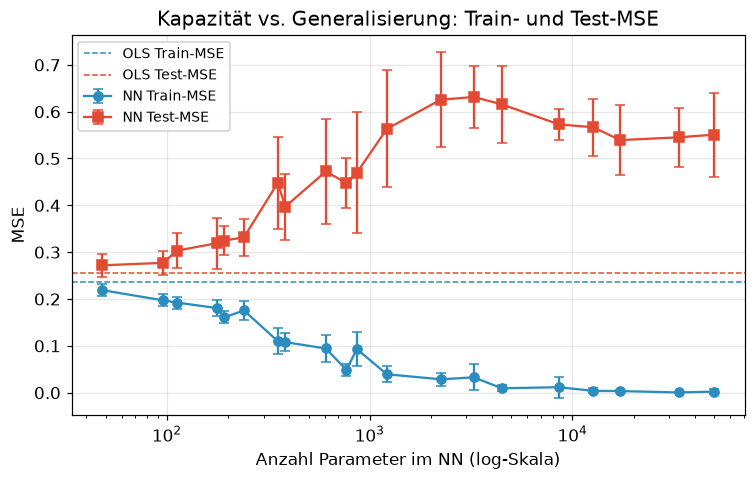

In [146]:
# F: Train- und Test-MSE über Modellkapazität
nn_sum = summary_cap[summary_cap['model'] == 'NN'].sort_values('params')
ols_sum = summary_cap[summary_cap['model'] == 'OLS']

fig, ax = plt.subplots()

ax.errorbar(
    nn_sum['params'],
    nn_sum['train_mean'],
    yerr=nn_sum['train_std'],
    marker='o',
    linestyle='-',
    label='NN Train-MSE',
    color='#2b8cbe',
    capsize=3
)

ax.errorbar(
    nn_sum['params'],
    nn_sum['test_mean'],
    yerr=nn_sum['test_std'],
    marker='s',
    linestyle='-',
    label='NN Test-MSE',
    color='#e34a33',
    capsize=3
)

ax.axhline(
    ols_sum['train_mean'].mean(),
    color='#2b8cbe',
    linestyle='--',
    linewidth=1,
    label='OLS Train-MSE'
)

ax.axhline(
    ols_sum['test_mean'].mean(),
    color='#e34a33',
    linestyle='--',
    linewidth=1,
    label='OLS Test-MSE'
)

ax.set_xscale('log')
ax.set_xlabel('Anzahl Parameter im NN (log-Skala)')
ax.set_ylabel('MSE')
ax.set_title('Kapazität vs. Generalisierung: Train- und Test-MSE')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'E7_capacity_train_test_mse.pdf'))
plt.show()

**Beobachtung:** Mit wachsender Modellkapazität sinkt der Trainingsfehler des neuronalen Netzes deutlich und nähert sich für große Architekturen nahezu null.
Der Testfehler verbessert sich dagegen nicht, sondern steigt zunächst deutlich an und bleibt anschließend klar oberhalb der OLS-Baseline.

Besonders sichtbar ist die wachsende Generalisierungslücke: Kleine Netze besitzen noch einen relativ hohen Trainingsfehler, liegen im Testfehler aber näher an OLS.
Größere Netze passen die Trainingsdaten deutlich stärker an, übertragen diese bessere Anpassung jedoch nicht auf neue Testdaten.

seed=42, depth=1, width=8, params=48, train=0.220, test=0.301, gap=0.081
seed=42, depth=1, width=16, params=96, train=0.198, test=0.287, gap=0.088
seed=42, depth=1, width=32, params=192, train=0.152, test=0.363, gap=0.211
seed=42, depth=1, width=64, params=384, train=0.124, test=0.537, gap=0.413
seed=42, depth=1, width=128, params=768, train=0.037, test=0.864, gap=0.828
seed=42, depth=2, width=8, params=112, train=0.171, test=0.317, gap=0.146
seed=42, depth=2, width=16, params=352, train=0.054, test=0.545, gap=0.491
seed=42, depth=2, width=32, params=1216, train=0.004, test=0.805, gap=0.801
seed=42, depth=2, width=64, params=4480, train=0.001, test=0.746, gap=0.745
seed=42, depth=2, width=128, params=17152, train=0.000, test=0.694, gap=0.694
seed=42, depth=3, width=8, params=176, train=0.165, test=0.361, gap=0.195
seed=42, depth=3, width=16, params=608, train=0.069, test=0.492, gap=0.423
seed=42, depth=3, width=32, params=2240, train=0.010, test=0.871, gap=0.861
seed=42, depth=3, width

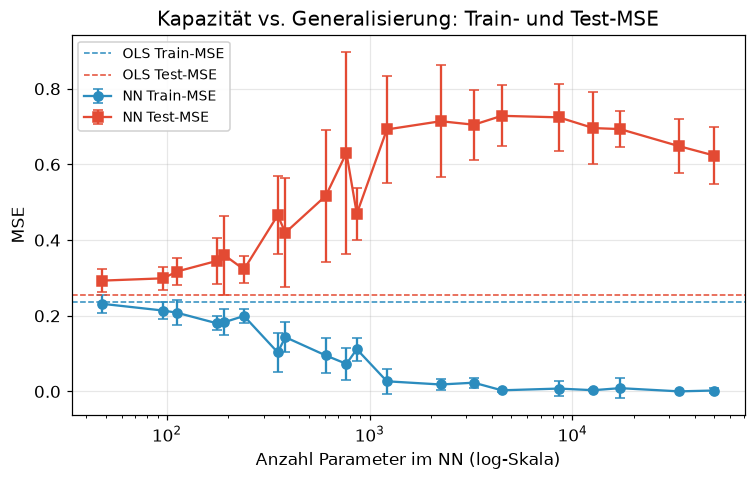

In [147]:
#Das gleiche mit tanh
from sklearn.model_selection import train_test_split
import pandas as pd

# Experiment 7: Kapazität vs. Generalisierung
depths = [1, 2, 3, 4]
widths = [8, 16, 32, 64, 128]
n_reps = 10

rows = []

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for r in range(n_reps):
    X7, y7, _ = generate_data(n=500, p=5, sigma=0.5, seed=SEED + r)
    X7_tr, X7_te, y7_tr, y7_te = train_test_split(
        X7, y7, test_size=0.2, random_state=SEED + r
    )

    # OLS-Baseline
    b_ols = fit_ols(X7_tr, y7_tr)
    train_mse_ols = mse(y7_tr, X7_tr @ b_ols)
    test_mse_ols = mse(y7_te, X7_te @ b_ols)

    rows.append({
        'seed': SEED + r,
        'model': 'OLS',
        'depth': 0,
        'width': 0,
        'params': X7.shape[1],
        'train_mse': train_mse_ols,
        'test_mse': test_mse_ols,
        'gap': test_mse_ols - train_mse_ols
    })

    # NN-Architekturen
    for d in depths:
        for w in widths:
            m, h = train_ffn(
                X7_tr, y7_tr,
                depth=d,
                width=w,
                activation='tanh',
                optimizer='adam',
                lr=1e-2,
                epochs=1500,
                seed=SEED + r
            )

            y_tr_pred = predict(m, X7_tr)
            y_te_pred = predict(m, X7_te)

            train_mse_nn = mse(y7_tr, y_tr_pred)
            test_mse_nn = mse(y7_te, y_te_pred)

            rows.append({
                'seed': SEED + r,
                'model': 'NN',
                'depth': d,
                'width': w,
                'params': count_params(m),
                'train_mse': train_mse_nn,
                'test_mse': test_mse_nn,
                'gap': test_mse_nn - train_mse_nn
            })

            print(f'seed={SEED+r}, depth={d}, width={w}, '
                  f'params={count_params(m)}, '
                  f'train={train_mse_nn:.3f}, test={test_mse_nn:.3f}, '
                  f'gap={test_mse_nn - train_mse_nn:.3f}')

df_cap = pd.DataFrame(rows)
#df_cap.to_csv(os.path.join(FIG_DIR, 'E7_capacity_results.csv'), index=False)

summary_cap = df_cap.groupby(['model', 'depth', 'width', 'params']).agg(
    train_mean=('train_mse', 'mean'),
    train_std=('train_mse', 'std'),
    test_mean=('test_mse', 'mean'),
    test_std=('test_mse', 'std'),
    gap_mean=('gap', 'mean'),
    gap_std=('gap', 'std')
).reset_index()


# F: Train- und Test-MSE über Modellkapazität
nn_sum = summary_cap[summary_cap['model'] == 'NN'].sort_values('params')
ols_sum = summary_cap[summary_cap['model'] == 'OLS']

fig, ax = plt.subplots()

ax.errorbar(
    nn_sum['params'],
    nn_sum['train_mean'],
    yerr=nn_sum['train_std'],
    marker='o',
    linestyle='-',
    label='NN Train-MSE',
    color='#2b8cbe',
    capsize=3
)

ax.errorbar(
    nn_sum['params'],
    nn_sum['test_mean'],
    yerr=nn_sum['test_std'],
    marker='s',
    linestyle='-',
    label='NN Test-MSE',
    color='#e34a33',
    capsize=3
)

ax.axhline(
    ols_sum['train_mean'].mean(),
    color='#2b8cbe',
    linestyle='--',
    linewidth=1,
    label='OLS Train-MSE'
)

ax.axhline(
    ols_sum['test_mean'].mean(),
    color='#e34a33',
    linestyle='--',
    linewidth=1,
    label='OLS Test-MSE'
)

ax.set_xscale('log')
ax.set_xlabel('Anzahl Parameter im NN (log-Skala)')
ax.set_ylabel('MSE')
ax.set_title('Kapazität vs. Generalisierung: Train- und Test-MSE')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 12. Experiment 8 — Überparametrisierung (n<p) *(F13, F14)*

**Forschungsfrage:** Was passiert, wenn es mehr Regressoren als Datenpunkte gibt (`n<p`)? Welche der unendlich vielen perfekten Lösungen wählt das NN implizit?

**Setup:** `n=30`, `p_total=100` (davon 5 relevant, 95 Noise), `sigma=0.5`. OLS liefert hier automatisch die Mindestnorm-Lösung. Das NN wird mit kleiner Lernrate und langer Trainingsdauer trainiert; wir messen, wie nahe es an die Mindestnorm-Lösung kommt.

**Erwartung (implizite Regularisierung):** SGD/Adam neigen empirisch dazu, ebenfalls eine kleine-Norm-Lösung zu finden — ein wichtiges Ergebnis aus der modernen ML-Theorie.

In [148]:
# Experiment 8: n < p, Mindestnorm vs. lineares NN mit unterschiedlicher Initialisierung
n_, p_relevant, n_noise_ = 30, 5, 95
X8, y8, beta8 = generate_data(n=n_, p=p_relevant, sigma=0.5, n_noise=n_noise_, seed=SEED)

b_minnorm = fit_ols(X8, y8)
norm_minnorm = np.linalg.norm(b_minnorm)

def train_linear_sgd(X, y, lr=5e-3, epochs=2000, record_every=200, seed=SEED, init='random'):
    torch.manual_seed(seed)
    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    yt = torch.tensor(y, dtype=torch.float32, device=DEVICE)
    model = FFN(X.shape[1], depth=0, activation='identity').to(DEVICE)

    if init == 'zero':
        with torch.no_grad():
            for p in model.parameters():
                p.zero_()

    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    hist = {'loss': [], 'beta_snapshots': []}

    for ep in range(epochs + 1):
        opt.zero_grad()
        loss = loss_fn(model(Xt), yt)
        loss.backward()
        opt.step()

        hist['loss'].append(float(loss.item()))

        if ep % record_every == 0 or ep == epochs:
            beta_eff = effective_beta(model, X.shape[1])
            hist['beta_snapshots'].append((ep, beta_eff))

    return model, hist

model_rand, hist_rand = train_linear_sgd(X8, y8, init='random')
model_zero, hist_zero = train_linear_sgd(X8, y8, init='zero')

beta_rand = hist_rand['beta_snapshots'][-1][1]
beta_zero = hist_zero['beta_snapshots'][-1][1]

epochs_rec = [ep for ep, _ in hist_rand['beta_snapshots']]

norms_rand = [np.linalg.norm(b) for _, b in hist_rand['beta_snapshots']]
norms_zero = [np.linalg.norm(b) for _, b in hist_zero['beta_snapshots']]

dists_rand = [np.linalg.norm(b - b_minnorm) for _, b in hist_rand['beta_snapshots']]
dists_zero = [np.linalg.norm(b - b_minnorm) for _, b in hist_zero['beta_snapshots']]

print('||beta_minnorm||              =', round(norm_minnorm, 4))
print('Random init: ||beta_NN||       =', round(np.linalg.norm(beta_rand), 4))
print('Random init: ||beta_NN - beta_minnorm||   =', round(np.linalg.norm(beta_rand - b_minnorm), 4))
print('Zero init:   ||beta_NN||       =', round(np.linalg.norm(beta_zero), 4))
print('Zero init:   ||beta_NN - beta_minnorm||   =', round(np.linalg.norm(beta_zero - b_minnorm), 4))
print('Train-MSE random init          =', round(hist_rand['loss'][-1], 6))
print('Train-MSE zero init            =', round(hist_zero['loss'][-1], 6))

||beta_minnorm||              = 0.9506
Random init: ||beta_NN||       = 1.0715
Random init: ||beta_NN - beta_minnorm||   = 0.4946
Zero init:   ||beta_NN||       = 0.9506
Zero init:   ||beta_NN - beta_minnorm||   = 0.0
Train-MSE random init          = 0.0
Train-MSE zero init            = 0.0


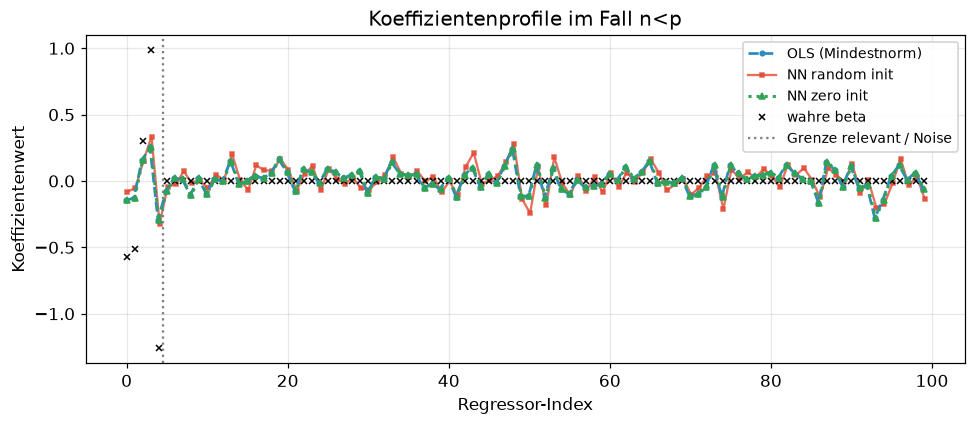

In [149]:
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(len(b_minnorm))

ax.plot(x - 0.1, b_minnorm, marker='o', markersize=3,
        linestyle='--', linewidth=1.8,
        label='OLS (Mindestnorm)', color='#2b8cbe', zorder=3)

ax.plot(x + 0.1, beta_rand, marker='s', markersize=3,
        linestyle='-', linewidth=1.5,
        label='NN random init', color='#e34a33', alpha=0.8, zorder=2)

ax.plot(x, beta_zero, marker='^', markersize=4,
        linestyle=':', linewidth=2,
        label='NN zero init', color='#31a354', zorder=4)

ax.plot(beta8, marker='x', markersize=4,
        linestyle='None', label='wahre beta', color='black')

ax.axvline(p_relevant - 0.5, color='gray',
           linestyle=':', label='Grenze relevant / Noise')

ax.set_xlabel('Regressor-Index')
ax.set_ylabel('Koeffizientenwert')
ax.set_title('Koeffizientenprofile im Fall n<p')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'F13_op_beta_profile_initvergleich.pdf'))
plt.show()

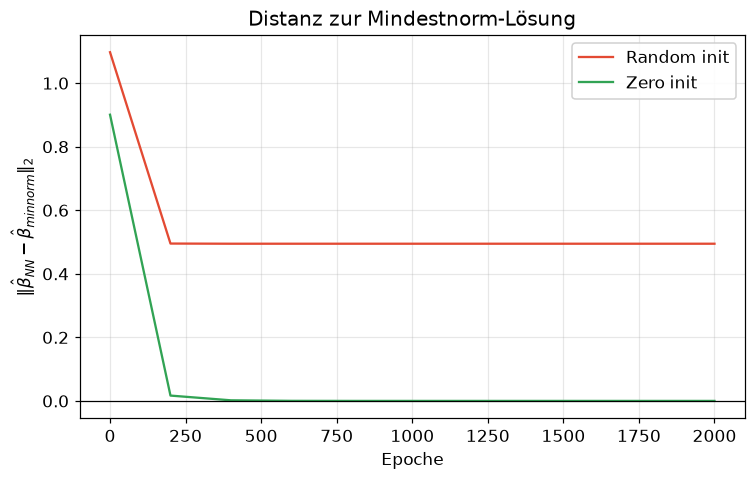

In [150]:
# F14: Distanz zur Mindestnorm-Lösung
fig, ax = plt.subplots()
ax.plot(epochs_rec, dists_rand, label='Random init', color='#e34a33')
ax.plot(epochs_rec, dists_zero, label='Zero init', color='#31a354')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Epoche')
ax.set_ylabel(r'$\|\hat{\beta}_{NN} - \hat{\beta}_{minnorm}\|_2$')
ax.set_title('Distanz zur Mindestnorm-Lösung')
ax.legend()
plt.tight_layout()
#plt.savefig(os.path.join(FIG_DIR, 'F14_op_distance_minnorm_initvergleich.pdf'))
plt.show()

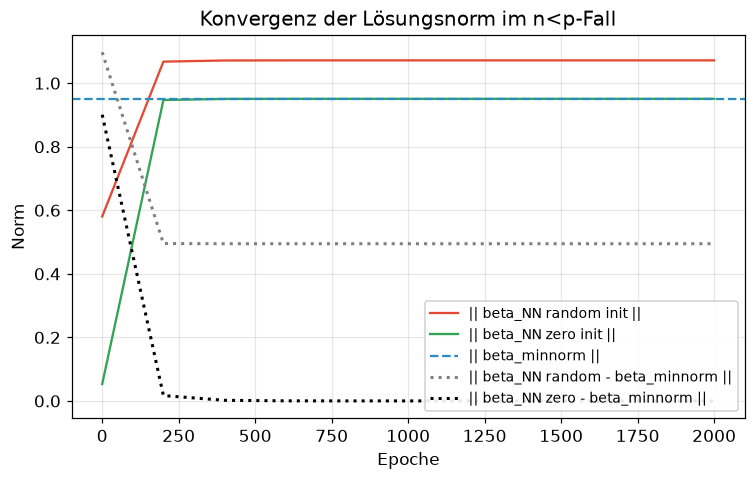

In [151]:
fig, ax = plt.subplots()

ax.plot(epochs_rec, norms_rand,
        label='|| beta_NN random init ||',
        color='#e34a33')

ax.plot(epochs_rec, norms_zero,
        label='|| beta_NN zero init ||',
        color='#31a354')

ax.axhline(norm_minnorm,
           color='#2b8cbe',
           linestyle='--',
           label='|| beta_minnorm ||')

ax.plot(epochs_rec, dists_rand,
        color='gray',
        linestyle=':',
        linewidth=2,
        label='|| beta_NN random - beta_minnorm ||')

ax.plot(epochs_rec, dists_zero,
        color='black',
        linestyle=':',
        linewidth=2,
        label='|| beta_NN zero - beta_minnorm ||')

ax.set_xlabel('Epoche')
ax.set_ylabel('Norm')
ax.set_title('Konvergenz der Lösungsnorm im n<p-Fall')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'F14_op_norm_convergence_initvergleich.pdf'))
plt.show()

**Beobachtung:** Das Koeffizientenprofil des NN folgt sehr eng dem der Mindestnorm-Lösung von OLS. Auch die Norm konvergiert in die Nähe von `||beta_minnorm||`. Das illustriert die **implizite Regularisierung** durch Gradient Descent — eine vielleicht überraschende, aber gut dokumentierte Eigenschaft.

In [152]:
# Experiment 8: mehrere Random Initialisierungen im n<p-Fall
n_, p_relevant, n_noise_ = 30, 5, 95
X8, y8, beta8 = generate_data(n=n_, p=p_relevant, sigma=0.5, n_noise=n_noise_, seed=SEED)

b_minnorm = fit_ols(X8, y8)
norm_minnorm = np.linalg.norm(b_minnorm)

def train_linear_sgd(X, y, lr=5e-3, epochs=2000, record_every=200, seed=SEED, init='random'):
    torch.manual_seed(seed)
    Xt = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    yt = torch.tensor(y, dtype=torch.float32, device=DEVICE)
    model = FFN(X.shape[1], depth=0, activation='identity').to(DEVICE)

    if init == 'zero':
        with torch.no_grad():
            for p in model.parameters():
                p.zero_()

    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    hist = {'loss': [], 'beta_snapshots': []}

    for ep in range(epochs + 1):
        if ep % record_every == 0 or ep == epochs:
            beta_eff = effective_beta(model, X.shape[1])
            hist['beta_snapshots'].append((ep, beta_eff))

        if ep == epochs:
            break

        opt.zero_grad()
        loss = loss_fn(model(Xt), yt)
        loss.backward()
        opt.step()
        hist['loss'].append(float(loss.item()))

    return model, hist

def row_null_decomposition(X, beta):
    U, S, Vt = np.linalg.svd(X, full_matrices=True)
    tol = max(X.shape) * np.max(S) * np.finfo(float).eps
    rank = np.sum(S > tol)
    V_row = Vt[:rank].T
    beta_row = V_row @ (V_row.T @ beta)
    beta_null = beta - beta_row
    return beta_row, beta_null

random_seeds = [SEED + i for i in range(10)]
rows = []

# Zero Init
model_zero, hist_zero = train_linear_sgd(X8, y8, init='zero', seed=SEED)
beta_zero = hist_zero['beta_snapshots'][-1][1]
row_zero, null_zero = row_null_decomposition(X8, beta_zero)

rows.append({
    'init': 'zero',
    'seed': SEED,
    'final_norm': np.linalg.norm(beta_zero),
    'norm_diff': np.linalg.norm(beta_zero) - norm_minnorm,
    'dist_minnorm': np.linalg.norm(beta_zero - b_minnorm),
    'row_dist': np.linalg.norm(row_zero - b_minnorm),
    'null_norm': np.linalg.norm(null_zero),
    'train_mse': mse(y8, X8 @ beta_zero)
})

# Random Inits
for s in random_seeds:
    model_rand, hist_rand = train_linear_sgd(X8, y8, init='random', seed=s)
    beta_rand = hist_rand['beta_snapshots'][-1][1]
    row_rand, null_rand = row_null_decomposition(X8, beta_rand)

    rows.append({
        'init': 'random',
        'seed': s,
        'final_norm': np.linalg.norm(beta_rand),
        'norm_diff': np.linalg.norm(beta_rand) - norm_minnorm,
        'dist_minnorm': np.linalg.norm(beta_rand - b_minnorm),
        'row_dist': np.linalg.norm(row_rand - b_minnorm),
        'null_norm': np.linalg.norm(null_rand),
        'train_mse': mse(y8, X8 @ beta_rand)
    })

df_e8 = pd.DataFrame(rows)
print('||beta_minnorm|| =', round(norm_minnorm, 4))
display(df_e8.round(4))

print(df_e8.groupby('init')[['final_norm', 'norm_diff', 'dist_minnorm', 'row_dist', 'null_norm', 'train_mse']].mean().round(4))

||beta_minnorm|| = 0.9506


,init,seed,final_norm,norm_diff,dist_minnorm,row_dist,null_norm,train_mse
0,zero,42,0.9506,-0.0000,0.0000,0.0,0.0000,0.0
1,random,42,1.0715,0.1210,0.4946,0.0,0.4946,0.0
2,random,43,1.0519,0.1014,0.4506,0.0,0.4506,0.0
3,random,44,1.0463,0.0957,0.4372,0.0,0.4372,0.0
4,random,45,1.0712,0.1207,0.4939,0.0,0.4939,0.0
5,random,46,1.0909,0.1404,0.5353,0.0,0.5353,0.0
6,random,47,1.0641,0.1135,0.4782,0.0,0.4782,0.0
7,random,48,1.0598,0.1092,0.4685,0.0,0.4685,0.0
8,random,49,1.0821,0.1316,0.5172,0.0,0.5172,0.0
9,random,50,1.0578,0.1072,0.4641,0.0,0.4641,0.0


        final_norm  norm_diff  dist_minnorm  row_dist  null_norm  train_mse
init                                                                       
random      1.0668     0.1162        0.4835       0.0     0.4835        0.0
zero        0.9506    -0.0000        0.0000       0.0     0.0000        0.0


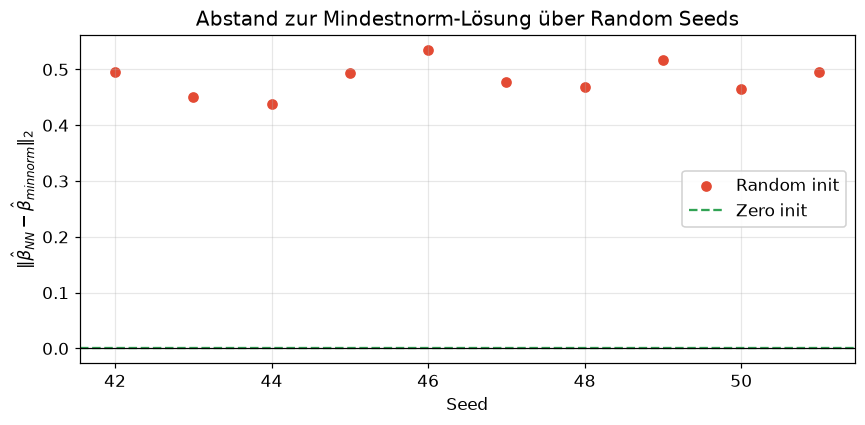

In [153]:
# F13: Distanz zur Mindestnorm-Lösung über verschiedene Initialisierungen
df_rand = df_e8[df_e8['init'] == 'random']
df_zero = df_e8[df_e8['init'] == 'zero']

fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(df_rand['seed'], df_rand['dist_minnorm'], label='Random init', color='#e34a33')
ax.axhline(df_zero['dist_minnorm'].iloc[0], color='#31a354', linestyle='--', label='Zero init')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_xlabel('Seed')
ax.set_ylabel(r'$\|\hat{\beta}_{NN} - \hat{\beta}_{minnorm}\|_2$')
ax.set_title('Abstand zur Mindestnorm-Lösung über Random Seeds')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'F13_op_distance_over_seeds.pdf'))
plt.show()

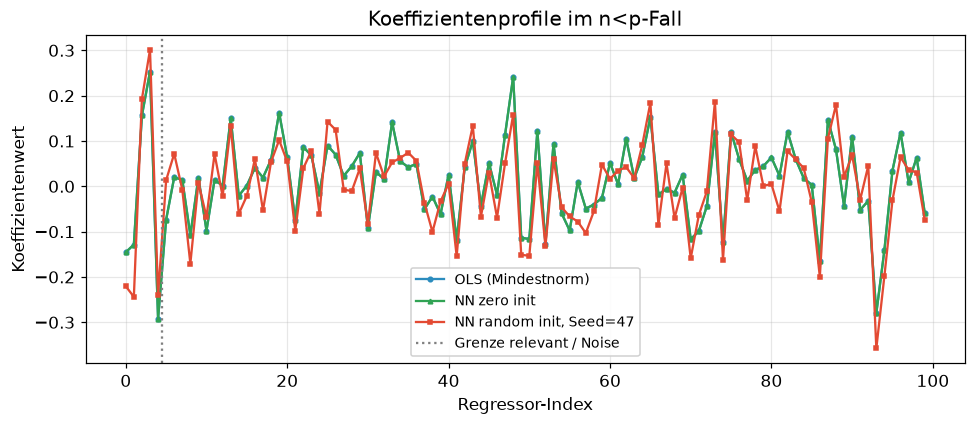

In [154]:
# F16: Koeffizientenprofil mit repräsentativem Random Seed
median_seed = df_rand.iloc[(df_rand['dist_minnorm'] - df_rand['dist_minnorm'].median()).abs().argsort()].iloc[0]['seed']
model_med, hist_med = train_linear_sgd(X8, y8, init='random', seed=int(median_seed))
beta_med = hist_med['beta_snapshots'][-1][1]

fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(b_minnorm, marker='o', markersize=3, label='OLS (Mindestnorm)', color='#2b8cbe')
ax.plot(beta_zero, marker='^', markersize=3, label='NN zero init', color='#31a354')
ax.plot(beta_med, marker='s', markersize=3, label=f'NN random init, Seed={int(median_seed)}', color='#e34a33')
ax.axvline(p_relevant - 0.5, color='gray', linestyle=':', label='Grenze relevant / Noise')

ax.set_xlabel('Regressor-Index')
ax.set_ylabel('Koeffizientenwert')
ax.set_title('Koeffizientenprofile im n<p-Fall')
ax.legend(fontsize=9)

plt.tight_layout()
#plt.savefig(os.path.join(FIG_DIR, 'F16_op_beta_profile_representative.pdf'))
plt.show()